In [9]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ------------------------------------------------------------
# Existing functions from src/
# ------------------------------------------------------------

from src.firing_rate_tuning import analyze_neuron

from src.number_decoding_analysis import (
    make_firing_rate_features,
    cv_lda_accuracy,
    temporal_grid_search,
)

# ------------------------------------------------------------
# Subjects
# ------------------------------------------------------------

SUBJECTS = [
    "YFF",
    "YFI",
    "YFJ",
    "YFK",
    "YFL",
    "YFM",
    "YFP",
    "YFR",
    "YFS",
    "YFT",
    "YFU",
]

# ------------------------------------------------------------
# MTL regions
# ------------------------------------------------------------

MTL_REGIONS = {
    "hpc",
    "ent",
    "ec",
    "amy",
    "phc",
    "para-hpc",
}

# ------------------------------------------------------------
# Arithmetic temporal bin sizes from paper
# ------------------------------------------------------------

BIN_SIZES_MS = [
    60,
    75,
    90,
    100,
    150,
    180,
    225,
    300,
    450,
    900,
]

# LDA shrinkage values
GAMMAS = [0.2, 0.5, 0.8]

# Figure 1N inclusion threshold
FR_THRESHOLD_HZ = 0.0069

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

(ROOT / "tables1").mkdir(exist_ok=True)
(ROOT / "figures1").mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Number of subjects:", len(SUBJECTS))
print("Setup complete.")

Project root: c:\Users\shafi\number-simplex-reproduction
Number of subjects: 11
Setup complete.


In [10]:
def analyze_figure1n_neuron(subject, neuron):

    # --------------------------------------------------------
    # Load neuron
    # --------------------------------------------------------

    out = analyze_neuron(
        subject=subject,
        neuron=neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    region = str(out["region"]).lower()

    # Ignore non-MTL neurons
    if region not in MTL_REGIONS:
        return None

    presentations = out["presentations"]
    spike_times = out["spike_times"]

    # --------------------------------------------------------
    # Mean firing rate
    # --------------------------------------------------------

    mean_fr_hz = float(
        presentations["firing_rate"].mean()
    )

    # Figure 1N threshold
    if mean_fr_hz <= FR_THRESHOLD_HZ:

        return {
            "subject": subject,
            "neuron": neuron,
            "region": region,
            "mean_firing_rate_hz": mean_fr_hz,
            "status": "threshold_excluded",
        }

    # --------------------------------------------------------
    # Firing-rate features
    # --------------------------------------------------------

    X_fr, y = make_firing_rate_features(
        presentations,
        spike_times,
    )

    # --------------------------------------------------------
    # Cross-validation folds
    # --------------------------------------------------------

    class_counts = (
        pd.Series(y)
        .value_counts()
    )

    min_class_count = int(
        class_counts.min()
    )

    n_splits = min(
        10,
        min_class_count,
    )

    # --------------------------------------------------------
    # FR decoding
    # --------------------------------------------------------

    try:

        fr_accuracy = cv_lda_accuracy(
            X_fr,
            y,
            gamma=0.2,
            n_splits=n_splits,
            random_state=42,
        )

    except ValueError as e:

        return {
            "subject": subject,
            "neuron": neuron,
            "region": region,
            "mean_firing_rate_hz": mean_fr_hz,
            "status": "FR_error",
            "error": str(e),
        }

    # --------------------------------------------------------
    # Temporal decoding
    # --------------------------------------------------------

    try:

        grid_table, best = temporal_grid_search(
            presentations,
            spike_times,
            bin_sizes=BIN_SIZES_MS,
            gammas=GAMMAS,
            n_splits=n_splits,
            random_state=42,
        )

    except ValueError as e:

        return {
            "subject": subject,
            "neuron": neuron,
            "region": region,
            "mean_firing_rate_hz": mean_fr_hz,
            "FR_accuracy": float(fr_accuracy),
            "status": "TC_error",
            "error": str(e),
        }

    # --------------------------------------------------------
    # Successful neuron
    # --------------------------------------------------------

    return {
        "subject": subject,
        "neuron": neuron,
        "region": region,

        "mean_firing_rate_hz":
            mean_fr_hz,

        "n_presentations":
            len(presentations),

        "min_class_count":
            min_class_count,

        "n_splits":
            n_splits,

        "FR_accuracy":
            float(fr_accuracy),

        "TC_accuracy":
            float(best["pooled_cv_accuracy"]),

        "best_bin_ms":
            int(best["bin_size_ms"]),

        "best_gamma":
            float(best["gamma"]),

        "status":
            "success",
    }


print("Single-neuron Figure 1N function ready.")

Single-neuron Figure 1N function ready.


In [11]:
def run_figure1n_subject(subject):

    print("\n" + "=" * 65)
    print("SUBJECT:", subject)
    print("=" * 65)

    # --------------------------------------------------------
    # Find total number of recorded neurons
    # --------------------------------------------------------

    info = analyze_neuron(
        subject=subject,
        neuron=1,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    total_neurons = info["total_neurons"]

    print("Total recorded neurons:", total_neurons)

    results = []

    # --------------------------------------------------------
    # Loop through neurons
    # --------------------------------------------------------

    for neuron in range(1, total_neurons + 1):

        result = analyze_figure1n_neuron(
            subject,
            neuron,
        )

        # Non-MTL neuron
        if result is None:
            continue

        results.append(result)

        status = result["status"]

        print(
            f"{subject} | "
            f"neuron {neuron}/{total_neurons} | "
            f"{result['region']} | "
            f"{status}"
        )

    # --------------------------------------------------------
    # Convert to dataframe
    # --------------------------------------------------------

    df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Save immediately
    # --------------------------------------------------------

    output_file = (
        ROOT
        / "tables1"
        / f"figure1N_{subject}_decoding.csv"
    )

    df.to_csv(
        output_file,
        index=False,
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print("\n" + "-" * 65)

    print(
        "MTL neurons:",
        len(df)
    )

    print("\nStatus:")

    print(
        df["status"].value_counts()
    )

    print("\nSaved:")
    print(output_file)

    return df


print("Subject runner ready.")

Subject runner ready.


In [8]:
YFF_results = run_figure1n_subject("YFF")


SUBJECT: YFF
Total recorded neurons: 54


KeyboardInterrupt: 

In [ ]:
YFF_results

,subject,neuron,region,mean_firing_rate_hz,n_presentations,min_class_count,n_splits,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status
0,YFF,9,ent,3.955148,109,7,7,0.100917,0.165138,180,0.2,success
1,YFF,10,hpc,16.666667,109,7,7,0.091743,0.155963,90,0.2,success
2,YFF,11,hpc,17.563710,109,7,7,0.110092,0.201835,100,0.5,success
3,YFF,12,hpc,17.003058,109,7,7,0.100917,0.174312,300,0.5,success
4,YFF,13,hpc,16.860347,109,7,7,0.146789,0.155963,100,0.8,success
5,YFF,14,hpc,18.868502,109,7,7,0.119266,0.192661,100,0.2,success
6,YFF,15,hpc,17.502548,109,7,7,0.055046,0.165138,75,0.5,success
7,YFF,16,hpc,13.129460,109,7,7,0.091743,0.146789,60,0.2,success
8,YFF,17,hpc,15.341488,109,7,7,0.155963,0.165138,150,0.2,success
9,YFF,27,hpc,16.044852,109,7,7,0.073394,0.146789,60,0.2,success


In [ ]:
YFI_results = run_figure1n_subject("YFI")


SUBJECT: YFI
Total recorded neurons: 38
YFI | neuron 1/38 | hpc | success
YFI | neuron 2/38 | hpc | success
YFI | neuron 3/38 | hpc | success
YFI | neuron 4/38 | hpc | success
YFI | neuron 5/38 | hpc | success
YFI | neuron 6/38 | hpc | success
YFI | neuron 7/38 | hpc | success
YFI | neuron 8/38 | hpc | success
YFI | neuron 9/38 | hpc | success
YFI | neuron 19/38 | hpc | success
YFI | neuron 20/38 | hpc | success
YFI | neuron 21/38 | hpc | success
YFI | neuron 22/38 | hpc | success
YFI | neuron 23/38 | hpc | success
YFI | neuron 24/38 | hpc | success
YFI | neuron 25/38 | hpc | success
YFI | neuron 26/38 | hpc | success
YFI | neuron 27/38 | hpc | success
YFI | neuron 28/38 | hpc | success
YFI | neuron 29/38 | hpc | success
YFI | neuron 30/38 | hpc | success
YFI | neuron 31/38 | ent | success
YFI | neuron 32/38 | ent | success
YFI | neuron 33/38 | ent | success
YFI | neuron 34/38 | ent | success
YFI | neuron 35/38 | ent | success
YFI | neuron 36/38 | ent | success
YFI | neuron 37/38 | en

In [ ]:
YFJ_results = run_figure1n_subject("YFJ")


SUBJECT: YFJ
Total recorded neurons: 62
YFJ | neuron 10/62 | hpc | success
YFJ | neuron 11/62 | hpc | success
YFJ | neuron 12/62 | hpc | success
YFJ | neuron 13/62 | hpc | success
YFJ | neuron 14/62 | hpc | success
YFJ | neuron 15/62 | hpc | success
YFJ | neuron 16/62 | hpc | success
YFJ | neuron 17/62 | hpc | success
YFJ | neuron 18/62 | hpc | success
YFJ | neuron 19/62 | hpc | success
YFJ | neuron 20/62 | hpc | success
YFJ | neuron 21/62 | hpc | success
YFJ | neuron 22/62 | hpc | success
YFJ | neuron 23/62 | hpc | success
YFJ | neuron 24/62 | hpc | success
YFJ | neuron 25/62 | hpc | success
YFJ | neuron 26/62 | hpc | success
YFJ | neuron 27/62 | hpc | success
YFJ | neuron 28/62 | hpc | success
YFJ | neuron 29/62 | hpc | success
YFJ | neuron 38/62 | hpc | success
YFJ | neuron 39/62 | hpc | success
YFJ | neuron 40/62 | hpc | success
YFJ | neuron 41/62 | hpc | success
YFJ | neuron 42/62 | hpc | success
YFJ | neuron 43/62 | hpc | success
YFJ | neuron 44/62 | hpc | success
YFJ | neuron 4

In [ ]:
YFK_results = run_figure1n_subject("YFK")


SUBJECT: YFK
Total recorded neurons: 68
YFK | neuron 25/68 | hpc | success
YFK | neuron 26/68 | hpc | success
YFK | neuron 27/68 | hpc | success
YFK | neuron 28/68 | hpc | success
YFK | neuron 29/68 | hpc | success
YFK | neuron 30/68 | hpc | success
YFK | neuron 31/68 | hpc | success
YFK | neuron 32/68 | hpc | success
YFK | neuron 33/68 | hpc | success
YFK | neuron 34/68 | hpc | success
YFK | neuron 35/68 | para-hpc | success
YFK | neuron 36/68 | para-hpc | success
YFK | neuron 37/68 | para-hpc | success
YFK | neuron 38/68 | para-hpc | success
YFK | neuron 39/68 | para-hpc | success
YFK | neuron 40/68 | para-hpc | success
YFK | neuron 41/68 | para-hpc | success
YFK | neuron 42/68 | para-hpc | success
YFK | neuron 43/68 | para-hpc | success
YFK | neuron 44/68 | para-hpc | success
YFK | neuron 45/68 | para-hpc | success
YFK | neuron 46/68 | para-hpc | success
YFK | neuron 47/68 | para-hpc | success
YFK | neuron 48/68 | hpc | success
YFK | neuron 49/68 | hpc | success
YFK | neuron 50/68 

In [ ]:
YFL_results = run_figure1n_subject("YFL")


SUBJECT: YFL
Total recorded neurons: 94
YFL | neuron 20/94 | hpc | success
YFL | neuron 21/94 | hpc | success
YFL | neuron 22/94 | hpc | success
YFL | neuron 23/94 | hpc | success
YFL | neuron 24/94 | hpc | success
YFL | neuron 25/94 | hpc | success
YFL | neuron 26/94 | hpc | success
YFL | neuron 27/94 | hpc | success
YFL | neuron 28/94 | hpc | threshold_excluded
YFL | neuron 29/94 | hpc | success
YFL | neuron 30/94 | hpc | success
YFL | neuron 31/94 | hpc | success
YFL | neuron 32/94 | hpc | success
YFL | neuron 33/94 | hpc | success
YFL | neuron 34/94 | hpc | success
YFL | neuron 35/94 | hpc | success
YFL | neuron 36/94 | hpc | success
YFL | neuron 37/94 | hpc | success
YFL | neuron 38/94 | hpc | success
YFL | neuron 39/94 | hpc | success
YFL | neuron 40/94 | hpc | success
YFL | neuron 59/94 | hpc | success
YFL | neuron 60/94 | hpc | success
YFL | neuron 61/94 | hpc | success
YFL | neuron 62/94 | hpc | success
YFL | neuron 63/94 | hpc | success
YFL | neuron 64/94 | hpc | success
YFL

In [ ]:
YFL_results

,subject,neuron,region,mean_firing_rate_hz,n_presentations,min_class_count,n_splits,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status
0,YFL,20,hpc,0.584795,114.0,4.0,4.0,0.078947,0.122807,150.0,0.5,success
1,YFL,21,hpc,0.185185,114.0,4.0,4.0,0.140351,0.157895,60.0,0.2,success
2,YFL,22,hpc,0.292398,114.0,4.0,4.0,0.157895,0.192982,225.0,0.2,success
3,YFL,23,hpc,1.725146,114.0,4.0,4.0,0.114035,0.131579,180.0,0.2,success
4,YFL,24,hpc,0.760234,114.0,4.0,4.0,0.149123,0.157895,450.0,0.8,success
5,YFL,25,hpc,0.545809,114.0,4.0,4.0,0.087719,0.184211,60.0,0.8,success
6,YFL,26,hpc,7.270955,114.0,4.0,4.0,0.105263,0.166667,180.0,0.2,success
7,YFL,27,hpc,4.307992,114.0,4.0,4.0,0.096491,0.122807,150.0,0.2,success
8,YFL,28,hpc,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,threshold_excluded
9,YFL,29,hpc,2.124756,114.0,4.0,4.0,0.087719,0.105263,300.0,0.2,success


In [ ]:
YFM_results = run_figure1n_subject("YFM")


SUBJECT: YFM
Total recorded neurons: 94
YFM | neuron 16/94 | hpc | success
YFM | neuron 17/94 | hpc | success
YFM | neuron 18/94 | hpc | success
YFM | neuron 19/94 | hpc | success
YFM | neuron 20/94 | hpc | success
YFM | neuron 21/94 | hpc | success
YFM | neuron 22/94 | hpc | success
YFM | neuron 23/94 | hpc | success
YFM | neuron 24/94 | hpc | success
YFM | neuron 25/94 | hpc | success
YFM | neuron 26/94 | hpc | success
YFM | neuron 34/94 | ent | success
YFM | neuron 35/94 | ent | success
YFM | neuron 36/94 | ent | success
YFM | neuron 37/94 | ent | success
YFM | neuron 38/94 | ent | success
YFM | neuron 39/94 | ent | success
YFM | neuron 40/94 | ent | success
YFM | neuron 41/94 | ent | success
YFM | neuron 42/94 | ent | success
YFM | neuron 43/94 | ent | success
YFM | neuron 44/94 | ent | success
YFM | neuron 45/94 | ent | success
YFM | neuron 46/94 | ent | success
YFM | neuron 47/94 | ent | success
YFM | neuron 48/94 | ent | success
YFM | neuron 49/94 | ent | success
YFM | neuron 5

In [ ]:
YFM_results

,subject,neuron,region,mean_firing_rate_hz,n_presentations,min_class_count,n_splits,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status,error
0,YFM,16,hpc,3.840156,114.0,4.0,4.0,0.078947,0.140351,100.0,0.2,success,NaN
1,YFM,17,hpc,2.339181,114.0,4.0,4.0,0.070175,0.184211,75.0,0.5,success,NaN
2,YFM,18,hpc,0.730994,114.0,4.0,4.0,0.061404,0.157895,75.0,0.8,success,NaN
3,YFM,19,hpc,0.536062,114.0,4.0,4.0,0.052632,0.114035,300.0,0.2,success,NaN
4,YFM,20,hpc,3.479532,114.0,4.0,4.0,0.070175,0.114035,60.0,0.8,success,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,YFM,90,ent,1.822612,114.0,4.0,4.0,0.035088,0.149123,100.0,0.2,success,NaN
57,YFM,91,ent,9.873294,114.0,4.0,4.0,0.087719,0.166667,450.0,0.8,success,NaN
58,YFM,92,ent,0.662768,114.0,4.0,4.0,0.166667,0.175439,60.0,0.2,success,NaN
59,YFM,93,ent,3.274854,114.0,4.0,4.0,0.140351,0.175439,90.0,0.2,success,NaN


In [ ]:
YFP_results = run_figure1n_subject("YFP")


SUBJECT: YFP
Total recorded neurons: 98
YFP | neuron 30/98 | hpc | success
YFP | neuron 31/98 | hpc | success
YFP | neuron 32/98 | hpc | success
YFP | neuron 33/98 | hpc | success
YFP | neuron 34/98 | hpc | success
YFP | neuron 35/98 | hpc | success
YFP | neuron 36/98 | hpc | success
YFP | neuron 37/98 | hpc | success
YFP | neuron 38/98 | hpc | success
YFP | neuron 39/98 | hpc | success
YFP | neuron 40/98 | hpc | success
YFP | neuron 41/98 | hpc | success
YFP | neuron 42/98 | hpc | FR_error
YFP | neuron 43/98 | hpc | success
YFP | neuron 44/98 | hpc | success
YFP | neuron 45/98 | hpc | success
YFP | neuron 46/98 | hpc | success
YFP | neuron 47/98 | hpc | success
YFP | neuron 74/98 | hpc | success
YFP | neuron 75/98 | hpc | success
YFP | neuron 76/98 | hpc | success
YFP | neuron 77/98 | hpc | success
YFP | neuron 78/98 | hpc | success
YFP | neuron 79/98 | hpc | success
YFP | neuron 80/98 | hpc | success
YFP | neuron 81/98 | hpc | success
YFP | neuron 82/98 | hpc | success
YFP | neuron 

In [ ]:
YFT_results = run_figure1n_subject("YFT")


SUBJECT: YFT
Total recorded neurons: 89
YFT | neuron 10/89 | ent | success
YFT | neuron 11/89 | ent | success
YFT | neuron 12/89 | ent | success
YFT | neuron 13/89 | ent | success
YFT | neuron 14/89 | ent | success
YFT | neuron 15/89 | ent | success
YFT | neuron 16/89 | ent | success
YFT | neuron 17/89 | ent | success
YFT | neuron 18/89 | hpc | success
YFT | neuron 19/89 | hpc | success
YFT | neuron 20/89 | hpc | success
YFT | neuron 21/89 | hpc | success
YFT | neuron 22/89 | hpc | success
YFT | neuron 23/89 | hpc | success
YFT | neuron 24/89 | hpc | success
YFT | neuron 25/89 | hpc | success
YFT | neuron 26/89 | hpc | success
YFT | neuron 27/89 | hpc | success
YFT | neuron 28/89 | hpc | success
YFT | neuron 29/89 | hpc | success
YFT | neuron 30/89 | hpc | success
YFT | neuron 31/89 | hpc | success
YFT | neuron 32/89 | hpc | success
YFT | neuron 33/89 | amy | success
YFT | neuron 34/89 | amy | success
YFT | neuron 35/89 | amy | success
YFT | neuron 36/89 | amy | success
YFT | neuron 3

In [ ]:
YFP_results

,subject,neuron,region,mean_firing_rate_hz,n_presentations,min_class_count,n_splits,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status,error
0,YFP,30,hpc,8.164557,158.0,9.0,9.0,0.088608,0.170886,225.0,0.5,success,NaN
1,YFP,31,hpc,0.914205,158.0,9.0,9.0,0.101266,0.145570,300.0,0.2,success,NaN
2,YFP,32,hpc,1.329114,158.0,9.0,9.0,0.158228,0.158228,900.0,0.2,success,NaN
3,YFP,33,hpc,2.011252,158.0,9.0,9.0,0.094937,0.126582,75.0,0.2,success,NaN
4,YFP,34,hpc,0.745429,158.0,9.0,9.0,0.075949,0.170886,150.0,0.5,success,NaN
5,YFP,35,hpc,1.090014,158.0,9.0,9.0,0.063291,0.145570,75.0,0.2,success,NaN
6,YFP,36,hpc,8.924051,158.0,9.0,9.0,0.120253,0.170886,150.0,0.5,success,NaN
7,YFP,37,hpc,0.998594,158.0,9.0,9.0,0.145570,0.151899,75.0,0.2,success,NaN
8,YFP,38,hpc,0.646976,158.0,9.0,9.0,0.050633,0.107595,60.0,0.2,success,NaN
9,YFP,39,hpc,0.056259,158.0,9.0,9.0,0.164557,0.164557,300.0,0.2,success,NaN


In [ ]:
YFP_results = run_figure1n_subject("YFP")


SUBJECT: YFP
Total recorded neurons: 98
YFP | neuron 30/98 | hpc | success
YFP | neuron 31/98 | hpc | success
YFP | neuron 32/98 | hpc | success
YFP | neuron 33/98 | hpc | success
YFP | neuron 34/98 | hpc | success
YFP | neuron 35/98 | hpc | success
YFP | neuron 36/98 | hpc | success
YFP | neuron 37/98 | hpc | success
YFP | neuron 38/98 | hpc | success
YFP | neuron 39/98 | hpc | success
YFP | neuron 40/98 | hpc | success
YFP | neuron 41/98 | hpc | success
YFP | neuron 42/98 | hpc | FR_error
YFP | neuron 43/98 | hpc | success
YFP | neuron 44/98 | hpc | success
YFP | neuron 45/98 | hpc | success
YFP | neuron 46/98 | hpc | success
YFP | neuron 47/98 | hpc | success
YFP | neuron 74/98 | hpc | success
YFP | neuron 75/98 | hpc | success
YFP | neuron 76/98 | hpc | success
YFP | neuron 77/98 | hpc | success
YFP | neuron 78/98 | hpc | success
YFP | neuron 79/98 | hpc | success
YFP | neuron 80/98 | hpc | success
YFP | neuron 81/98 | hpc | success
YFP | neuron 82/98 | hpc | success
YFP | neuron 

In [ ]:
YFP_results

,subject,neuron,region,mean_firing_rate_hz,n_presentations,min_class_count,n_splits,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status,error
0,YFP,30,hpc,8.164557,158.0,9.0,9.0,0.088608,0.170886,225.0,0.5,success,NaN
1,YFP,31,hpc,0.914205,158.0,9.0,9.0,0.101266,0.145570,300.0,0.2,success,NaN
2,YFP,32,hpc,1.329114,158.0,9.0,9.0,0.158228,0.158228,900.0,0.2,success,NaN
3,YFP,33,hpc,2.011252,158.0,9.0,9.0,0.094937,0.126582,75.0,0.2,success,NaN
4,YFP,34,hpc,0.745429,158.0,9.0,9.0,0.075949,0.170886,150.0,0.5,success,NaN
5,YFP,35,hpc,1.090014,158.0,9.0,9.0,0.063291,0.145570,75.0,0.2,success,NaN
6,YFP,36,hpc,8.924051,158.0,9.0,9.0,0.120253,0.170886,150.0,0.5,success,NaN
7,YFP,37,hpc,0.998594,158.0,9.0,9.0,0.145570,0.151899,75.0,0.2,success,NaN
8,YFP,38,hpc,0.646976,158.0,9.0,9.0,0.050633,0.107595,60.0,0.2,success,NaN
9,YFP,39,hpc,0.056259,158.0,9.0,9.0,0.164557,0.164557,300.0,0.2,success,NaN


In [ ]:
YFR_results = run_figure1n_subject("YFR")


SUBJECT: YFR
Total recorded neurons: 78
YFR | neuron 1/78 | hpc | success
YFR | neuron 2/78 | hpc | success
YFR | neuron 3/78 | hpc | success
YFR | neuron 4/78 | hpc | success
YFR | neuron 5/78 | hpc | success
YFR | neuron 6/78 | hpc | success
YFR | neuron 7/78 | hpc | success
YFR | neuron 8/78 | hpc | success
YFR | neuron 9/78 | hpc | success
YFR | neuron 10/78 | hpc | success
YFR | neuron 11/78 | hpc | success
YFR | neuron 12/78 | hpc | success
YFR | neuron 13/78 | hpc | success
YFR | neuron 14/78 | hpc | success
YFR | neuron 15/78 | hpc | threshold_excluded
YFR | neuron 16/78 | hpc | success
YFR | neuron 17/78 | hpc | success
YFR | neuron 18/78 | hpc | success
YFR | neuron 19/78 | hpc | success
YFR | neuron 20/78 | hpc | success
YFR | neuron 21/78 | hpc | success
YFR | neuron 22/78 | hpc | success
YFR | neuron 23/78 | hpc | success
YFR | neuron 24/78 | hpc | success
YFR | neuron 25/78 | amy | success
YFR | neuron 26/78 | amy | success
YFR | neuron 27/78 | amy | success
YFR | neuron

In [ ]:
YFS_results = run_figure1n_subject("YFS")


SUBJECT: YFS
Total recorded neurons: 96
YFS | neuron 27/96 | amy | success
YFS | neuron 28/96 | amy | success
YFS | neuron 29/96 | amy | success
YFS | neuron 30/96 | amy | success
YFS | neuron 31/96 | amy | success
YFS | neuron 32/96 | amy | success
YFS | neuron 33/96 | amy | success
YFS | neuron 34/96 | amy | success
YFS | neuron 35/96 | amy | success
YFS | neuron 36/96 | amy | success
YFS | neuron 37/96 | amy | success
YFS | neuron 38/96 | hpc | success
YFS | neuron 39/96 | hpc | success
YFS | neuron 40/96 | hpc | success
YFS | neuron 41/96 | hpc | success
YFS | neuron 42/96 | hpc | success
YFS | neuron 43/96 | hpc | success
YFS | neuron 44/96 | hpc | success
YFS | neuron 45/96 | hpc | success
YFS | neuron 46/96 | hpc | success
YFS | neuron 47/96 | hpc | success
YFS | neuron 48/96 | hpc | FR_error
YFS | neuron 49/96 | hpc | success
YFS | neuron 50/96 | hpc | success
YFS | neuron 51/96 | hpc | success
YFS | neuron 52/96 | hpc | success
YFS | neuron 53/96 | hpc | success
YFS | neuron 

In [ ]:
YFU_results = run_figure1n_subject("YFU")


SUBJECT: YFU
Total recorded neurons: 78
YFU | neuron 1/78 | amy | success
YFU | neuron 2/78 | amy | success
YFU | neuron 3/78 | amy | success
YFU | neuron 4/78 | amy | success
YFU | neuron 5/78 | amy | success
YFU | neuron 6/78 | amy | success
YFU | neuron 7/78 | amy | success
YFU | neuron 8/78 | amy | success
YFU | neuron 9/78 | amy | success
YFU | neuron 10/78 | amy | success
YFU | neuron 11/78 | amy | success
YFU | neuron 12/78 | amy | success
YFU | neuron 21/78 | hpc | success
YFU | neuron 22/78 | hpc | success
YFU | neuron 23/78 | hpc | success
YFU | neuron 24/78 | hpc | success
YFU | neuron 25/78 | hpc | success
YFU | neuron 26/78 | hpc | success
YFU | neuron 27/78 | hpc | success
YFU | neuron 28/78 | hpc | success
YFU | neuron 29/78 | hpc | success
YFU | neuron 30/78 | hpc | success
YFU | neuron 31/78 | hpc | success
YFU | neuron 32/78 | hpc | success
YFU | neuron 33/78 | hpc | success
YFU | neuron 34/78 | hpc | success
YFU | neuron 35/78 | hpc | success
YFU | neuron 36/78 | hp

In [ ]:
SUBJECTS

['YFF', 'YFI', 'YFJ', 'YFK', 'YFL', 'YFM', 'YFP', 'YFR', 'YFS', 'YFT', 'YFU']

In [ ]:
all_subject_dfs = []

for subject in SUBJECTS:

    file = (
        ROOT
        / "tables1"
        / f"figure1N_{subject}_decoding.csv"
    )

    df = pd.read_csv(file)

    all_subject_dfs.append(df)


figure1n_all = pd.concat(
    all_subject_dfs,
    ignore_index=True,
)


print(
    "Total MTL neurons:",
    len(figure1n_all)
)


print("\nStatus counts:")

print(
    figure1n_all["status"]
    .value_counts()
)


print("\nCounts by subject:")

print(
    figure1n_all
    .groupby("subject")
    .size()
)

Total MTL neurons: 554

Status counts:
status
success               519
FR_error                4
threshold_excluded      2
Name: count, dtype: int64

Counts by subject:
subject
YFF    37
YFI    29
YFJ    45
YFK    44
YFL    57
YFM    61
YFP    43
YFR    65
YFS    59
YFT    52
YFU    62
dtype: int64


In [ ]:
for subject in SUBJECTS:

    file = (
        ROOT
        / "tables1"
        / f"figure1N_{subject}_decoding.csv"
    )

    if file.exists():
        print(f"{subject}: FOUND")
    else:
        print(f"{subject}: MISSING")

YFF: FOUND
YFI: FOUND
YFJ: FOUND
YFK: FOUND
YFL: FOUND
YFM: FOUND
YFP: FOUND
YFR: FOUND
YFS: FOUND
YFT: FOUND
YFU: FOUND


In [ ]:
problems = figure1n_all[
    figure1n_all["status"] != "success"
].copy()


problems[
    [
        "subject",
        "neuron",
        "region",
        "mean_firing_rate_hz",
        "status",
        "error",
    ]
]

,subject,neuron,region,mean_firing_rate_hz,status,error
37,YFI,1,hpc,10.427350,NaN,NaN
38,YFI,2,hpc,13.183761,NaN,NaN
39,YFI,3,hpc,16.217949,NaN,NaN
40,YFI,4,hpc,11.688034,NaN,NaN
41,YFI,5,hpc,3.279915,NaN,NaN
42,YFI,6,hpc,8.888889,NaN,NaN
43,YFI,7,hpc,9.626068,NaN,NaN
44,YFI,8,hpc,6.079060,NaN,NaN
45,YFI,9,hpc,11.805556,NaN,NaN
46,YFI,19,hpc,15.363248,NaN,NaN


In [ ]:
problem_neurons = figure1n_all[
    figure1n_all["status"] != "success"
][
    [
        "subject",
        "neuron",
        "region",
        "mean_firing_rate_hz",
        "status",
        "error",
    ]
].copy()

problem_neurons

,subject,neuron,region,mean_firing_rate_hz,status,error
37,YFI,1,hpc,10.427350,NaN,NaN
38,YFI,2,hpc,13.183761,NaN,NaN
39,YFI,3,hpc,16.217949,NaN,NaN
40,YFI,4,hpc,11.688034,NaN,NaN
41,YFI,5,hpc,3.279915,NaN,NaN
42,YFI,6,hpc,8.888889,NaN,NaN
43,YFI,7,hpc,9.626068,NaN,NaN
44,YFI,8,hpc,6.079060,NaN,NaN
45,YFI,9,hpc,11.805556,NaN,NaN
46,YFI,19,hpc,15.363248,NaN,NaN


In [ ]:
FR_ERROR_NEURONS = [
    ("YFM", 64),
    ("YFP", 42),
    ("YFP", 83),
    ("YFS", 48),
]

for subject, neuron in FR_ERROR_NEURONS:

    out = analyze_neuron(
        subject=subject,
        neuron=neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    presentations = out["presentations"]

    print("\n" + "=" * 60)
    print(subject, "neuron", neuron)
    print("=" * 60)

    print(
        "Number of presentations:",
        len(presentations)
    )

    print(
        "Mean firing rate:",
        presentations["firing_rate"].mean()
    )

    print(
        "Presentations with zero spikes:",
        (presentations["firing_rate"] == 0).sum()
    )

    print(
        "Presentations with > 0 spikes:",
        (presentations["firing_rate"] > 0).sum()
    )

    print("\nFiring-rate values:")
    print(
        presentations["firing_rate"]
        .value_counts()
        .sort_index()
    )


YFM neuron 64
Number of presentations: 114
Mean firing rate: 0.009746588693957116
Presentations with zero spikes: 113
Presentations with > 0 spikes: 1

Firing-rate values:
firing_rate
0.000000    113
1.111111      1
Name: count, dtype: int64

YFP neuron 42
Number of presentations: 158
Mean firing rate: 0.007032348804500704
Presentations with zero spikes: 157
Presentations with > 0 spikes: 1

Firing-rate values:
firing_rate
0.000000    157
1.111111      1
Name: count, dtype: int64

YFP neuron 83
Number of presentations: 158
Mean firing rate: 0.007032348804500704
Presentations with zero spikes: 157
Presentations with > 0 spikes: 1

Firing-rate values:
firing_rate
0.000000    157
1.111111      1
Name: count, dtype: int64

YFS neuron 48
Number of presentations: 264
Mean firing rate: 0.016835016835016835
Presentations with zero spikes: 262
Presentations with > 0 spikes: 2

Firing-rate values:
firing_rate
0.000000    262
1.111111      1
3.333333      1
Name: count, dtype: int64


In [ ]:
for subject, neuron in [
    ("YFL", 28),
    ("YFR", 15),
]:

    out = analyze_neuron(
        subject=subject,
        neuron=neuron,
        root=ROOT,
        plot=False,
        verbose=False,
    )

    presentations = out["presentations"]

    print("\n" + "=" * 60)
    print(subject, "neuron", neuron)
    print("=" * 60)

    print("Presentations:", len(presentations))
    print(
        "Mean operand-window FR:",
        presentations["firing_rate"].mean()
    )

    print(
        "Zero-spike presentations:",
        (presentations["firing_rate"] == 0).sum()
    )

    print(
        "Nonzero presentations:",
        (presentations["firing_rate"] > 0).sum()
    )

    print("\nFR values:")
    print(
        presentations["firing_rate"]
        .value_counts()
        .sort_index()
    )

    print("\nTotal spikes in complete spike train:")
    print(len(out["spike_times"]))


YFL neuron 28
Presentations: 114
Mean operand-window FR: 0.0
Zero-spike presentations: 114
Nonzero presentations: 0

FR values:
firing_rate
0.0    114
Name: count, dtype: int64

Total spikes in complete spike train:
12

YFR neuron 15
Presentations: 266
Mean operand-window FR: 0.004177109440267335
Zero-spike presentations: 265
Nonzero presentations: 1

FR values:
firing_rate
0.000000    265
1.111111      1
Name: count, dtype: int64

Total spikes in complete spike train:
70


In [ ]:
import inspect

from src import number_decoding_analysis

print(
    inspect.getsource(
        number_decoding_analysis.cv_lda_accuracy
    )
)

def cv_lda_accuracy(
    X,
    y,
    gamma,
    n_splits=10,
    random_state=42,
    return_folds=False,
):
    """
    Stratified K-fold LDA.

    Final accuracy is pooled held-out accuracy:

        total correct held-out predictions
        ----------------------------------
        total held-out predictions

    Every observation is held out exactly once.
    """

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    all_true = []
    all_pred = []

    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y),
        start=1,
    ):

        X_train = X[train_idx].copy()
        X_test = X[test_idx].copy()

        y_train = y[train_idx]
        y_test = y[test_idx]

        (
            X_train,
            X_test,
            keep,
        ) = _remove_zero_variance_features(
            X_train,
            X_test,
            y_train,
        )

        if X_train.shape[1] ==

In [ ]:
print(
    inspect.getsource(
        number_decoding_analysis._remove_zero_variance_features
    )
)

def _remove_zero_variance_features(
    X_train,
    X_test,
    y_train,
):
    """
    Determine feature removal using TRAINING DATA ONLY.
    """

    keep = np.ones(
        X_train.shape[1],
        dtype=bool,
    )

    for j in range(X_train.shape[1]):

        class_variances = []

        for c in np.unique(y_train):

            values = X_train[
                y_train == c,
                j
            ]

            if len(values) > 1:

                class_variances.append(
                    np.var(
                        values,
                        ddof=1,
                    )
                )

        if (
            len(class_variances) == 0
            or
            np.all(
                np.asarray(class_variances) == 0
            )
        ):
            keep[j] = False

    return (
        X_train[:, keep],
        X_test[:, keep],
        keep,
    )



In [ ]:
import importlib
import src.number_decoding_analysis as nda

importlib.reload(nda)

from src.number_decoding_analysis import (
    make_firing_rate_features,
    cv_lda_accuracy,
    temporal_grid_search,
)

print("number_decoding_analysis.py reloaded.")

number_decoding_analysis.py reloaded.


In [ ]:
test_YFM64 = analyze_figure1n_neuron(
    "YFM",
    64,
)

test_YFM64

{'subject': 'YFM',
 'neuron': 64,
 'region': 'hpc',
 'mean_firing_rate_hz': 0.009746588693957116,
 'n_presentations': 114,
 'min_class_count': 4,
 'n_splits': 4,
 'FR_accuracy': 0.14035087719298245,
 'TC_accuracy': 0.14035087719298245,
 'best_bin_ms': 60,
 'best_gamma': 0.2,
 'status': 'success'}

In [ ]:
problem_neurons = [
    ("YFM", 64),
    ("YFP", 42),
    ("YFP", 83),
    ("YFS", 48),
]

results_problem = []

for subject, neuron in problem_neurons:
    result = analyze_figure1n_neuron(
        subject,
        neuron,
    )

    results_problem.append(result)

problem_df = pd.DataFrame(results_problem)

problem_df[
    [
        "subject",
        "neuron",
        "region",
        "mean_firing_rate_hz",
        "n_presentations",
        "n_splits",
        "FR_accuracy",
        "TC_accuracy",
        "best_bin_ms",
        "best_gamma",
        "status",
    ]
]

,subject,neuron,region,mean_firing_rate_hz,n_presentations,n_splits,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status
0,YFM,64,hpc,0.009747,114,4,0.140351,0.140351,60,0.2,success
1,YFP,42,hpc,0.007032,158,9,0.139241,0.139241,60,0.2,success
2,YFP,83,hpc,0.007032,158,9,0.139241,0.139241,60,0.2,success
3,YFS,48,hpc,0.016835,264,10,0.121212,0.121212,60,0.2,success


In [ ]:
out = analyze_neuron(
    "YFR",
    15,
    plot=False,
    verbose=False,
)

print(out.keys())

dict_keys(['subject', 'matlab_row', 'python_row', 'region', 'total_neurons', 'total_mtl_neurons', 'region_counts', 'mtl_region_counts', 'presentations', 'tuning', 'spike_times', 'figure', 'axis'])


In [ ]:
import h5py
from pathlib import Path

for subject in ["YFL", "YFR"]:

    subject_dir = ROOT / "data" / "raw" / subject / "arithmetic"

    candidates = [
        subject_dir / "spikes.mat",
        subject_dir / "spikesArithmetic.mat",
    ]

    spike_file = next(
        p for p in candidates if p.exists()
    )

    with h5py.File(spike_file, "r") as f:

        if "spikes" in f:
            g = f["spikes"]

        elif "spikesArithmetic" in f:
            g = f["spikesArithmetic"]

        else:
            raise KeyError(
                f"Could not find spike group for {subject}"
            )

        print("\n", subject)
        print("file:", spike_file.name)
        print("group:", g.name)
        print("keys:", list(g.keys()))
        print("attrs:", dict(g.attrs))



 YFL
file: spikesArithmetic.mat
group: /spikesArithmetic
keys: ['data', 'ir', 'jc']
attrs: {'MATLAB_class': np.bytes_(b'logical'), 'MATLAB_int_decode': np.int32(1), 'MATLAB_sparse': np.uint64(94)}

 YFR
file: spikes.mat
group: /spikes
keys: ['data', 'ir', 'jc']
attrs: {'MATLAB_class': np.bytes_(b'logical'), 'MATLAB_int_decode': np.int32(1), 'MATLAB_sparse': np.uint64(78)}


In [ ]:
import h5py
import numpy as np

for subject, neuron in [
    ("YFL", 28),
    ("YFR", 15),
]:

    subject_dir = ROOT / "data" / "raw" / subject / "arithmetic"

    candidates = [
        subject_dir / "spikes.mat",
        subject_dir / "spikesArithmetic.mat",
    ]

    spike_file = next(
        p for p in candidates if p.exists()
    )

    with h5py.File(spike_file, "r") as f:

        if "spikes" in f:
            g = f["spikes"]
        else:
            g = f["spikesArithmetic"]

        ir = np.asarray(g["ir"]).ravel()
        jc = np.asarray(g["jc"]).ravel()

        # Number of columns in CSC sparse matrix
        n_time_bins = len(jc) - 1

        # Our data use approximately 1-ms spike-matrix columns
        duration_s = n_time_bins / 1000.0

        # MATLAB neuron number -> Python row
        python_row = neuron - 1

        # Count entries belonging to this neuron
        total_spikes = np.sum(ir == python_row)

        full_recording_rate_hz = (
            total_spikes / duration_s
        )

        print(f"\n{subject} neuron {neuron}")
        print(f"time columns:       {n_time_bins}")
        print(f"duration (s):        {duration_s:.3f}")
        print(f"total spikes:        {total_spikes}")
        print(
            f"full-recording rate: "
            f"{full_recording_rate_hz:.6f} Hz"
        )
        print(
            f"above 0.007 Hz:      "
            f"{full_recording_rate_hz > 0.007}"
        )


YFL neuron 28
time columns:       937166
duration (s):        937.166
total spikes:        12
full-recording rate: 0.012805 Hz
above 0.007 Hz:      True

YFR neuron 15
time columns:       3075950
duration (s):        3075.950
total spikes:        70
full-recording rate: 0.022757 Hz
above 0.007 Hz:      True


In [ ]:
# ============================================================
# PATCH THE 4 PREVIOUSLY FAILED NEURONS
# WITHOUT RERUNNING THE POPULATION
# ============================================================

problem_neurons = [
    ("YFM", 64),
    ("YFP", 42),
    ("YFP", 83),
    ("YFS", 48),
]

for subject, neuron in problem_neurons:

    print(f"Updating {subject} neuron {neuron}...")

    # Recompute only this neuron
    new_result = analyze_figure1n_neuron(
        subject,
        neuron,
    )

    # Load existing subject table
    csv_path = (
        ROOT
        / "tables1"
        / f"figure1N_{subject}_decoding.csv"
    )

    df = pd.read_csv(csv_path)

    # Find this neuron
    mask = (
        df["neuron"] == neuron
    )

    if mask.sum() != 1:
        raise ValueError(
            f"Expected exactly one row for "
            f"{subject} neuron {neuron}, "
            f"found {mask.sum()}."
        )

    # Replace values
    for key, value in new_result.items():

        if key in df.columns:
            df.loc[mask, key] = value

    # Save corrected subject table
    df.to_csv(
        csv_path,
        index=False,
    )

    print(
        f"  status = {new_result['status']}, "
        f"FR = {new_result['FR_accuracy']:.4f}, "
        f"TC = {new_result['TC_accuracy']:.4f}"
    )

print("\nDone. Four rows updated.")

Updating YFM neuron 64...
  status = success, FR = 0.1404, TC = 0.1404
Updating YFP neuron 42...
  status = success, FR = 0.1392, TC = 0.1392
Updating YFP neuron 83...
  status = success, FR = 0.1392, TC = 0.1392
Updating YFS neuron 48...
  status = success, FR = 0.1212, TC = 0.1212

Done. Four rows updated.


In [ ]:
# ============================================================
# COMBINE ALL 11 SUBJECT TABLES + SANITY CHECK
# ============================================================

all_subject_tables = []

for subject in SUBJECTS:

    csv_path = (
        ROOT
        / "tables1"
        / f"figure1N_{subject}_decoding.csv"
    )

    df = pd.read_csv(csv_path)

    all_subject_tables.append(df)

# Combine all subjects
figure1N_df = pd.concat(
    all_subject_tables,
    ignore_index=True,
)

print("========================================")
print("FIGURE 1N POPULATION CHECK")
print("========================================")

print(
    "\nTotal MTL neurons:",
    len(figure1N_df)
)

print("\nStatus counts:")
print(
    figure1N_df["status"].value_counts(
        dropna=False
    )
)

print("\nNeurons per subject:")
print(
    figure1N_df.groupby("subject").size()
)

# Successful neurons only
success_df = figure1N_df[
    figure1N_df["status"] == "success"
].copy()

print(
    "\nSuccessful decoding results:",
    len(success_df)
)

print(
    "\nMissing FR accuracies:",
    success_df["FR_accuracy"].isna().sum()
)

print(
    "Missing TC accuracies:",
    success_df["TC_accuracy"].isna().sum()
)

print("\nMean decoding accuracies:")

print(
    "FR:",
    success_df["FR_accuracy"].mean()
)

print(
    "Temporal:",
    success_df["TC_accuracy"].mean()
)

print(
    "\nMean temporal improvement:",
    (
        success_df["TC_accuracy"]
        - success_df["FR_accuracy"]
    ).mean()
)

# Save combined table
combined_path = (
    ROOT
    / "tables1"
    / "figure1N_all_subjects_decoding.csv"
)

figure1N_df.to_csv(
    combined_path,
    index=False,
)

print(
    "\nSaved:",
    combined_path
)

FIGURE 1N POPULATION CHECK

Total MTL neurons: 554

Status counts:
status
success               523
NaN                    29
threshold_excluded      2
Name: count, dtype: int64

Neurons per subject:
subject
YFF    37
YFI    29
YFJ    45
YFK    44
YFL    57
YFM    61
YFP    43
YFR    65
YFS    59
YFT    52
YFU    62
dtype: int64

Successful decoding results: 523

Missing FR accuracies: 0
Missing TC accuracies: 0

Mean decoding accuracies:
FR: 0.1054367594983625
Temporal: 0.14486297750164412

Mean temporal improvement: 0.03942621800328165

Saved: c:\Users\shafi\number-simplex-reproduction\tables1\figure1N_all_subjects_decoding.csv


In [ ]:
# ============================================================
# INVESTIGATE THE 29 ROWS WITH MISSING STATUS
# ============================================================

missing_status = figure1N_df[
    figure1N_df["status"].isna()
].copy()

print(
    "Number of missing-status rows:",
    len(missing_status)
)

print("\nMissing rows by subject:")
print(
    missing_status.groupby("subject").size()
)

print("\nRows:")
display(
    missing_status[
        [
            "subject",
            "neuron",
            "region",
            "mean_firing_rate_hz",
            "FR_accuracy",
            "TC_accuracy",
            "best_bin_ms",
            "best_gamma",
            "status",
        ]
    ]
)

Number of missing-status rows: 29

Missing rows by subject:
subject
YFI    29
dtype: int64

Rows:


,subject,neuron,region,mean_firing_rate_hz,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,status
37,YFI,1,hpc,10.427350,0.115385,0.144231,90.0,0.2,NaN
38,YFI,2,hpc,13.183761,0.125000,0.192308,60.0,0.2,NaN
39,YFI,3,hpc,16.217949,0.115385,0.163462,90.0,0.2,NaN
40,YFI,4,hpc,11.688034,0.182692,0.182692,900.0,0.2,NaN
41,YFI,5,hpc,3.279915,0.105769,0.163462,180.0,0.2,NaN
42,YFI,6,hpc,8.888889,0.057692,0.153846,75.0,0.2,NaN
43,YFI,7,hpc,9.626068,0.067308,0.105769,100.0,0.2,NaN
44,YFI,8,hpc,6.079060,0.125000,0.201923,60.0,0.2,NaN
45,YFI,9,hpc,11.805556,0.105769,0.153846,225.0,0.8,NaN
46,YFI,19,hpc,15.363248,0.115385,0.173077,450.0,0.2,NaN


In [ ]:
# ============================================================
# FINAL COMBINATION OF ALL 11 SUBJECTS
# ============================================================

all_subject_tables = []

for subject in SUBJECTS:

    csv_path = (
        ROOT
        / "tables1"
        / f"figure1N_{subject}_decoding.csv"
    )

    df = pd.read_csv(csv_path)
    all_subject_tables.append(df)

figure1N_df = pd.concat(
    all_subject_tables,
    ignore_index=True,
)

print("========================================")
print("FINAL FIGURE 1N DATASET")
print("========================================")

print("\nTotal MTL neurons:", len(figure1N_df))

print("\nStatus:")
print(
    figure1N_df["status"].value_counts(
        dropna=False
    )
)

success_df = figure1N_df[
    figure1N_df["status"] == "success"
].copy()

print("\nSuccessful:", len(success_df))

print(
    "Missing FR:",
    success_df["FR_accuracy"].isna().sum()
)

print(
    "Missing temporal:",
    success_df["TC_accuracy"].isna().sum()
)

mean_fr = success_df["FR_accuracy"].mean()
mean_tc = success_df["TC_accuracy"].mean()

improvement = (
    success_df["TC_accuracy"]
    - success_df["FR_accuracy"]
)

print(
    "\nMean FR accuracy:",
    mean_fr
)

print(
    "Mean temporal accuracy:",
    mean_tc
)

print(
    "Mean improvement:",
    improvement.mean()
)

print(
    "Mean improvement (percentage points):",
    100 * improvement.mean()
)

print(
    "\nTemporal > FR:",
    (improvement > 0).sum()
)

print(
    "Temporal = FR:",
    (improvement == 0).sum()
)

print(
    "Temporal < FR:",
    (improvement < 0).sum()
)

# Save final combined dataset
combined_path = (
    ROOT
    / "tables1"
    / "figure1N_all_subjects_decoding.csv"
)

figure1N_df.to_csv(
    combined_path,
    index=False,
)

print("\nSaved:")
print(combined_path)

FINAL FIGURE 1N DATASET

Total MTL neurons: 554

Status:
status
success               552
threshold_excluded      2
Name: count, dtype: int64

Successful: 552
Missing FR: 0
Missing temporal: 0

Mean FR accuracy: 0.1059245440118961
Mean temporal accuracy: 0.14582265663791502
Mean improvement: 0.039898112626018944
Mean improvement (percentage points): 3.9898112626018944

Temporal > FR: 496
Temporal = FR: 56
Temporal < FR: 0

Saved:
c:\Users\shafi\number-simplex-reproduction\tables1\figure1N_all_subjects_decoding.csv


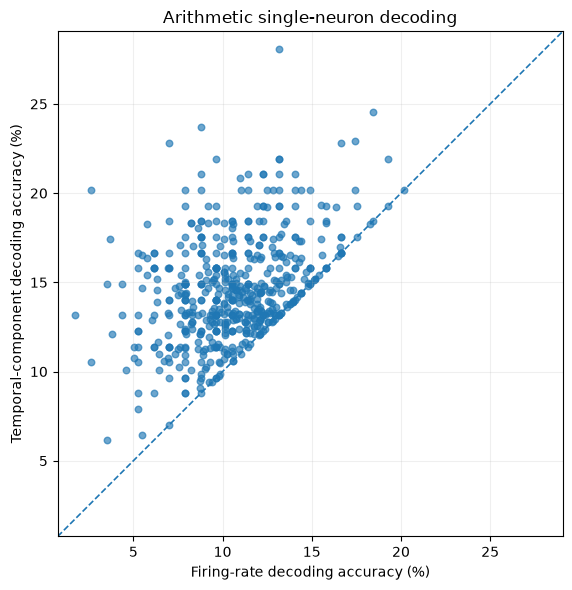

Saved:
c:\Users\shafi\number-simplex-reproduction\figures1\figure1N_arithmetic_decoding.png


In [ ]:
# ============================================================
# FIGURE 1N
# Firing-rate decoding vs temporal-component decoding
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

x = 100 * success_df["FR_accuracy"]
y = 100 * success_df["TC_accuracy"]

# Scatter
ax.scatter(
    x,
    y,
    s=22,
    alpha=0.65,
)

# Common plotting limits
lower = min(x.min(), y.min())
upper = max(x.max(), y.max())

padding = 1.0

lower -= padding
upper += padding

# Identity line: temporal = firing rate
ax.plot(
    [lower, upper],
    [lower, upper],
    "--",
    linewidth=1.2,
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_xlabel(
    "Firing-rate decoding accuracy (%)"
)

ax.set_ylabel(
    "Temporal-component decoding accuracy (%)"
)

ax.set_title(
    "Arithmetic single-neuron decoding"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

figure_path = (
    ROOT
    / "figures1"
    / "figure1N_arithmetic_decoding.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(figure_path)

In [ ]:
# ============================================================
# PAIRED T-TEST
# FIGURE 1N: FIRING RATE vs TEMPORAL DECODING
# ============================================================

from scipy.stats import ttest_rel

fr = success_df["FR_accuracy"].to_numpy()
tc = success_df["TC_accuracy"].to_numpy()

# Paired t-test
t_stat, p_value = ttest_rel(
    tc,
    fr,
)

# Temporal advantage for each neuron
difference = tc - fr

print("========================================")
print("FIGURE 1N PAIRED T-TEST")
print("========================================")

print("Number of neurons:", len(fr))

print(
    "\nMean firing-rate accuracy:",
    100 * fr.mean(),
    "%"
)

print(
    "Mean temporal accuracy:",
    100 * tc.mean(),
    "%"
)

print(
    "Mean temporal advantage:",
    100 * difference.mean(),
    "percentage points"
)

print(
    "\nPaired t statistic:",
    t_stat
)

print(
    "Degrees of freedom:",
    len(fr) - 1
)

print(
    "p-value:",
    p_value
)

FIGURE 1N PAIRED T-TEST
Number of neurons: 552

Mean firing-rate accuracy: 10.59245440118961 %
Mean temporal accuracy: 14.582265663791501 %
Mean temporal advantage: 3.9898112626018944 percentage points

Paired t statistic: 29.826296921183435
Degrees of freedom: 551
p-value: 4.397928681493731e-117


In [ ]:
# ============================================================
# PAIRED T-TEST
# FIGURE 1N: FIRING RATE vs TEMPORAL DECODING
# ============================================================

from scipy.stats import ttest_rel

fr = success_df["FR_accuracy"].to_numpy()
tc = success_df["TC_accuracy"].to_numpy()

difference = tc - fr

# Paired t-test
t_stat, p_value = ttest_rel(
    tc,
    fr,
)

alpha = 0.05

print("========================================")
print("FIGURE 1N PAIRED T-TEST")
print("========================================")

print("Number of neurons:", len(fr))

print(
    "\nMean firing-rate accuracy:",
    100 * fr.mean(),
    "%"
)

print(
    "Mean temporal accuracy:",
    100 * tc.mean(),
    "%"
)

print(
    "Mean temporal advantage:",
    100 * difference.mean(),
    "percentage points"
)

print(
    "\nPaired t statistic:",
    t_stat
)

print(
    "Degrees of freedom:",
    len(fr) - 1
)

print(
    "p-value:",
    p_value
)

print("\n========================================")
print("CONCLUSION")
print("========================================")

if p_value < alpha:

    if difference.mean() > 0:
        print(
            "Reject H0 at alpha = 0.05."
        )
        print(
            "Temporal-component decoding accuracy is "
            "significantly higher than firing-rate "
            "decoding accuracy."
        )
        print(
            "This provides statistical evidence for "
            "a temporal decoding advantage."
        )

    else:
        print(
            "Reject H0 at alpha = 0.05."
        )
        print(
            "Firing-rate decoding accuracy is "
            "significantly higher than temporal-component "
            "decoding accuracy."
        )

else:

    print(
        "Fail to reject H0 at alpha = 0.05."
    )

    print(
        "We do not find statistically significant "
        "evidence of a difference between the two "
        "decoding representations."
    )

FIGURE 1N PAIRED T-TEST
Number of neurons: 552

Mean firing-rate accuracy: 10.59245440118961 %
Mean temporal accuracy: 14.582265663791501 %
Mean temporal advantage: 3.9898112626018944 percentage points

Paired t statistic: 29.826296921183435
Degrees of freedom: 551
p-value: 4.397928681493731e-117

CONCLUSION
Reject H0 at alpha = 0.05.
Temporal-component decoding accuracy is significantly higher than firing-rate decoding accuracy.
This provides statistical evidence for a temporal decoding advantage.


In [12]:
# ============================================================
# FINAL FIGURE 1N REPRODUCTION
# WITH SUMMARY STATISTICS ON THE RIGHT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

fr = success_df["FR_accuracy"].to_numpy()
tc = success_df["TC_accuracy"].to_numpy()

x = 100 * fr
y = 100 * tc

difference = tc - fr


# ------------------------------------------------------------
# STATISTICS
# ------------------------------------------------------------

n_neurons = len(fr)

mean_fr = 100 * fr.mean()
mean_tc = 100 * tc.mean()
mean_advantage = 100 * difference.mean()

t_stat, p_value = ttest_rel(
    tc,
    fr,
)

df_t = n_neurons - 1


# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 6)
)


# Scatter: one point = one neuron
ax.scatter(
    x,
    y,
    s=22,
    alpha=0.65,
)


# ------------------------------------------------------------
# IDENTITY LINE
# ------------------------------------------------------------

lower = min(x.min(), y.min()) - 1
upper = max(x.max(), y.max()) + 1

ax.plot(
    [lower, upper],
    [lower, upper],
    "--",
    linewidth=1.2,
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)

ax.set_aspect(
    "equal",
    adjustable="box",
)


# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_xlabel(
    "Firing-rate decoding accuracy (%)",
    fontsize=11,
)

ax.set_ylabel(
    "Temporal-component decoding accuracy (%)",
    fontsize=11,
)

ax.set_title(
    "Arithmetic single-neuron decoding",
    fontsize=13,
)

ax.grid(
    alpha=0.2
)


# ------------------------------------------------------------
# STATISTICS BOX
# ------------------------------------------------------------

stats_text = (
    f"N = {n_neurons} neurons\n\n"
    f"Mean firing-rate accuracy\n"
    f"= {mean_fr:.2f}%\n\n"
    f"Mean temporal accuracy\n"
    f"= {mean_tc:.2f}%\n\n"
    f"Temporal advantage\n"
    f"= {mean_advantage:.2f} pp\n\n"
    f"Paired t-test\n"
    f"t({df_t}) = {t_stat:.2f}\n"
    f"p = {p_value:.2e}"
)

fig.text(
    0.73,
    0.53,
    stats_text,
    fontsize=10,
    va="center",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="0.6",
        alpha=0.95,
    ),
)


# Leave room on right for statistics
plt.tight_layout(
    rect=[0, 0, 0.72, 1]
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

figure_path = (
    ROOT
    / "figures1"
    / "figure1N_arithmetic_decoding_final.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(figure_path)

NameError: name 'success_df' is not defined

****************************Fig 1M********************

In [13]:
import inspect
import src.number_decoding_analysis as nda

print(inspect.getsource(nda.cv_lda_accuracy))
print("\n" + "="*70 + "\n")
print(inspect.getsource(nda.make_temporal_features))

def cv_lda_accuracy(
    X,
    y,
    gamma,
    n_splits=10,
    random_state=42,
    return_folds=False,
):
    """
    Stratified K-fold LDA.

    Final accuracy is pooled held-out accuracy:

        total correct held-out predictions
        ----------------------------------
        total held-out predictions

    Every observation is held out exactly once.

    If zero-within-class-variance removal leaves no usable
    features in a training fold, use a deterministic
    prior-only prediction. Because the classifier uses
    uniform class priors, all classes are tied, so the
    smallest class label is chosen deterministically.
    """

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    all_true = []
    all_pred = []

    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y),
        start=1,
    ):

        X_train = X[train_idx].copy()
        X_test = X[test_idx].copy()



In [14]:
# ============================================================
# CHECK CURRENT DECODING FUNCTIONS
# Do not run permutation analysis yet
# ============================================================

import inspect
import src.number_decoding_analysis as nda

print("make_firing_rate_features:")
print(inspect.signature(nda.make_firing_rate_features))

print("\nmake_temporal_features:")
print(inspect.signature(nda.make_temporal_features))

print("\ncv_lda_accuracy:")
print(inspect.signature(nda.cv_lda_accuracy))

print("\ntemporal_grid_search:")
print(inspect.signature(nda.temporal_grid_search))

make_firing_rate_features:
(presentations, spike_times, window_start=50, window_end=950)

make_temporal_features:
(presentations, spike_times, bin_size, window_start=50, window_end=950)

cv_lda_accuracy:
(X, y, gamma, n_splits=10, random_state=42, return_folds=False)

temporal_grid_search:
(presentations, spike_times, bin_sizes=[60, 75, 90, 100, 150, 180, 225, 300, 450, 900], gammas=[0.2, 0.5, 0.8], n_splits=10, random_state=42)


SAVED FIGURE 1N RESULT
Neuron: YFU.hpc.43
FR accuracy: 12.15%
TC accuracy: 16.40%
Best temporal bin: 150 ms
Best gamma: 0.2

FEATURE CHECK
Presentations: 494
FR feature shape: (494, 1)
TC feature shape: (494, 6)
Temporal bin edges: [ 50. 200. 350. 500. 650. 800. 950.]

CV folds: 10

OBSERVED ACCURACY CHECK
Saved FR:      12.1457%
Recomputed FR: 12.1457%

Saved TC:      16.3968%
Recomputed TC: 16.3968%

Observed accuracies match. Proceeding to permutations...

YFU.hpc.43 PERMUTATION RESULTS

FIRING-RATE REPRESENTATION
Observed accuracy: 12.15%
Mean shuffled accuracy: 11.24%
Permutation p-value: 0.343284
Numeral-coding neuron: False

TEMPORAL REPRESENTATION
Observed accuracy: 16.40%
Mean shuffled accuracy: 11.19%
Permutation p-value: 0.009950
Numeral-coding neuron: True

CONCLUSION
FR: not significant (p >= 0.05).
TC: significant numeral coding (p < 0.05).


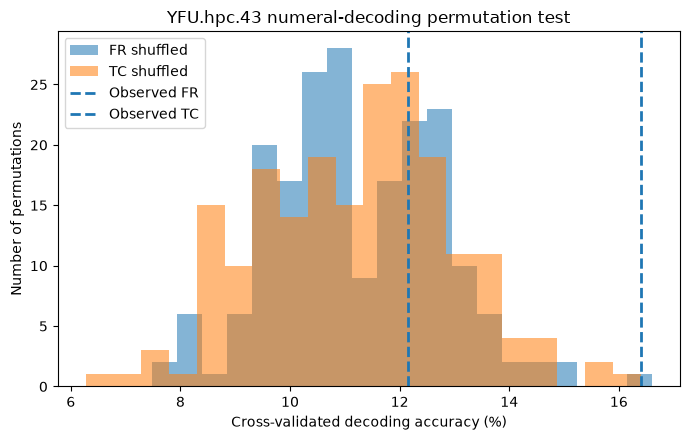

In [15]:
# ============================================================
# FIGURE 1M DEVELOPMENT
# ONE NEURON FIRST: YFU.hpc.43
#
# Restart-safe cell
# ============================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. PROJECT + IMPORTS
# ============================================================

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.firing_rate_tuning import analyze_neuron

from src.number_decoding_analysis import (
    make_firing_rate_features,
    make_temporal_features,
    cv_lda_accuracy,
)


# ============================================================
# 1. SETTINGS
# ============================================================

SUBJECT = "YFU"
NEURON = 43

N_PERM = 200
ALPHA = 0.05

# Reproducible permutation sequence
PERM_SEED = 12345


# ============================================================
# 2. LOAD SAVED FIGURE 1N RESULTS
# ============================================================

csv_path = (
    ROOT
    / "tables1"
    / "figure1N_all_subjects_decoding.csv"
)

figure1N_df = pd.read_csv(
    csv_path
)

row = figure1N_df[
    (figure1N_df["subject"] == SUBJECT)
    & (figure1N_df["neuron"] == NEURON)
]

if len(row) != 1:
    raise ValueError(
        f"Expected one row for "
        f"{SUBJECT} neuron {NEURON}, "
        f"found {len(row)}."
    )

row = row.iloc[0]


observed_fr = float(
    row["FR_accuracy"]
)

observed_tc = float(
    row["TC_accuracy"]
)

best_bin = int(
    row["best_bin_ms"]
)

best_gamma = float(
    row["best_gamma"]
)


print("========================================")
print("SAVED FIGURE 1N RESULT")
print("========================================")

print(
    f"Neuron: {SUBJECT}.hpc.{NEURON}"
)

print(
    f"FR accuracy: {100 * observed_fr:.2f}%"
)

print(
    f"TC accuracy: {100 * observed_tc:.2f}%"
)

print(
    f"Best temporal bin: {best_bin} ms"
)

print(
    f"Best gamma: {best_gamma}"
)


# ============================================================
# 3. LOAD RAW DATA FOR THIS NEURON
# ============================================================

out = analyze_neuron(
    SUBJECT,
    NEURON,
    root=ROOT,
    plot=False,
    verbose=False,
)

presentations = out["presentations"]
spike_times = out["spike_times"]


# ============================================================
# 4. BUILD FEATURES
# ============================================================

# Firing-rate representation
X_fr, y_fr = make_firing_rate_features(
    presentations,
    spike_times,
)

# Temporal representation
# IMPORTANT:
# use the bin size already selected in Figure 1N
X_tc, y_tc, bin_edges = make_temporal_features(
    presentations,
    spike_times,
    best_bin,
)


if not np.array_equal(
    y_fr,
    y_tc,
):
    raise ValueError(
        "FR and TC labels do not match."
    )

y = y_fr


print("\n========================================")
print("FEATURE CHECK")
print("========================================")

print(
    "Presentations:",
    len(y)
)

print(
    "FR feature shape:",
    X_fr.shape
)

print(
    "TC feature shape:",
    X_tc.shape
)

print(
    "Temporal bin edges:",
    bin_edges
)


# ============================================================
# 5. DETERMINE NUMBER OF CV FOLDS
# ============================================================

class_counts = pd.Series(
    y
).value_counts()

min_class_count = int(
    class_counts.min()
)

n_splits = min(
    10,
    min_class_count,
)

print(
    "\nCV folds:",
    n_splits
)


# ============================================================
# 6. RECOMPUTE OBSERVED ACCURACIES
#
# This MUST reproduce the saved Figure 1N values.
# ============================================================

check_fr = cv_lda_accuracy(
    X_fr,
    y,
    gamma=0.2,
    n_splits=n_splits,
    random_state=42,
)

check_tc = cv_lda_accuracy(
    X_tc,
    y,
    gamma=best_gamma,
    n_splits=n_splits,
    random_state=42,
)


print("\n========================================")
print("OBSERVED ACCURACY CHECK")
print("========================================")

print(
    f"Saved FR:      {100 * observed_fr:.4f}%"
)

print(
    f"Recomputed FR: {100 * check_fr:.4f}%"
)

print(
    f"\nSaved TC:      {100 * observed_tc:.4f}%"
)

print(
    f"Recomputed TC: {100 * check_tc:.4f}%"
)


# Strict consistency check

if not np.isclose(
    observed_fr,
    check_fr,
):
    raise ValueError(
        "FR accuracy does not match saved Figure 1N result."
    )

if not np.isclose(
    observed_tc,
    check_tc,
):
    raise ValueError(
        "TC accuracy does not match saved Figure 1N result."
    )


print(
    "\nObserved accuracies match. "
    "Proceeding to permutations..."
)


# ============================================================
# 7. PERMUTATION TEST
# ============================================================

rng = np.random.default_rng(
    PERM_SEED
)

fr_null = np.empty(
    N_PERM
)

tc_null = np.empty(
    N_PERM
)


for p in range(N_PERM):

    # Shuffle numeral labels
    y_perm = rng.permutation(
        y
    )

    # --------------------------------------------------------
    # Firing-rate permutation
    # --------------------------------------------------------

    fr_null[p] = cv_lda_accuracy(
        X_fr,
        y_perm,
        gamma=0.2,
        n_splits=n_splits,
        random_state=42,
    )

    # --------------------------------------------------------
    # Temporal permutation
    #
    # Keep best bin and gamma FIXED.
    # Do NOT repeat temporal grid search.
    # --------------------------------------------------------

    tc_null[p] = cv_lda_accuracy(
        X_tc,
        y_perm,
        gamma=best_gamma,
        n_splits=n_splits,
        random_state=42,
    )


# ============================================================
# 8. PERMUTATION P-VALUES
# ============================================================

p_fr = (
    1
    + np.sum(
        fr_null >= observed_fr
    )
) / (
    N_PERM + 1
)


p_tc = (
    1
    + np.sum(
        tc_null >= observed_tc
    )
) / (
    N_PERM + 1
)


fr_coding = (
    p_fr < ALPHA
)

tc_coding = (
    p_tc < ALPHA
)


# ============================================================
# 9. PRINT RESULTS
# ============================================================

print("\n========================================")
print("YFU.hpc.43 PERMUTATION RESULTS")
print("========================================")


print("\nFIRING-RATE REPRESENTATION")

print(
    f"Observed accuracy: "
    f"{100 * observed_fr:.2f}%"
)

print(
    f"Mean shuffled accuracy: "
    f"{100 * fr_null.mean():.2f}%"
)

print(
    f"Permutation p-value: "
    f"{p_fr:.6f}"
)

print(
    f"Numeral-coding neuron: "
    f"{fr_coding}"
)


print("\nTEMPORAL REPRESENTATION")

print(
    f"Observed accuracy: "
    f"{100 * observed_tc:.2f}%"
)

print(
    f"Mean shuffled accuracy: "
    f"{100 * tc_null.mean():.2f}%"
)

print(
    f"Permutation p-value: "
    f"{p_tc:.6f}"
)

print(
    f"Numeral-coding neuron: "
    f"{tc_coding}"
)


# ============================================================
# 10. CONCLUSION
# ============================================================

print("\n========================================")
print("CONCLUSION")
print("========================================")

if fr_coding:
    print(
        "FR: significant numeral coding "
        "(p < 0.05)."
    )
else:
    print(
        "FR: not significant "
        "(p >= 0.05)."
    )


if tc_coding:
    print(
        "TC: significant numeral coding "
        "(p < 0.05)."
    )
else:
    print(
        "TC: not significant "
        "(p >= 0.05)."
    )


# ============================================================
# 11. VISUALIZE NULL DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.hist(
    100 * fr_null,
    bins=20,
    alpha=0.55,
    label="FR shuffled",
)

ax.hist(
    100 * tc_null,
    bins=20,
    alpha=0.55,
    label="TC shuffled",
)

ax.axvline(
    100 * observed_fr,
    linestyle="--",
    linewidth=2,
    label="Observed FR",
)

ax.axvline(
    100 * observed_tc,
    linestyle="--",
    linewidth=2,
    label="Observed TC",
)

ax.set_xlabel(
    "Cross-validated decoding accuracy (%)"
)

ax.set_ylabel(
    "Number of permutations"
)

ax.set_title(
    "YFU.hpc.43 numeral-decoding permutation test"
)

ax.legend()

plt.tight_layout()
plt.show()

In [16]:
def permutation_test_decoding(
    X,
    y,
    observed_accuracy,
    gamma,
    n_permutations=200,
    n_splits=10,
    cv_random_state=42,
    permutation_seed=12345,
    alpha=0.05,
):
    """
    Permutation test for single-neuron numeral decoding.

    Parameters
    ----------
    X : ndarray
        Neural features.

    y : ndarray
        Numeral labels.

    observed_accuracy : float
        Cross-validated decoding accuracy obtained using
        the real numeral labels.

    gamma : float
        LDA shrinkage parameter.

    n_permutations : int
        Number of label permutations.

    n_splits : int
        Number of cross-validation folds.

    cv_random_state : int
        Random seed used by cross-validation.

    permutation_seed : int
        Seed controlling label permutations.

    alpha : float
        Significance level used to classify the neuron.

    Returns
    -------
    dict
        Dictionary containing observed accuracy,
        permutation distribution, p-value, and coding status.
    """

    X = np.asarray(X)
    y = np.asarray(y)

    rng = np.random.default_rng(
        permutation_seed
    )

    null_accuracies = np.empty(
        n_permutations,
        dtype=float,
    )

    # --------------------------------------------------------
    # Shuffle numeral labels
    # --------------------------------------------------------

    for p in range(n_permutations):

        y_perm = rng.permutation(
            y
        )

        null_accuracies[p] = cv_lda_accuracy(
            X,
            y_perm,
            gamma=gamma,
            n_splits=n_splits,
            random_state=cv_random_state,
        )

    # --------------------------------------------------------
    # Permutation p-value
    # --------------------------------------------------------

    n_equal_or_better = int(
        np.sum(
            null_accuracies
            >= observed_accuracy
        )
    )

    p_value = (
        1 + n_equal_or_better
    ) / (
        n_permutations + 1
    )

    is_coding = (
        p_value < alpha
    )

    return {
        "observed_accuracy":
            observed_accuracy,

        "null_mean":
            null_accuracies.mean(),

        "null_std":
            null_accuracies.std(ddof=1),

        "n_equal_or_better":
            n_equal_or_better,

        "p_value":
            p_value,

        "is_coding":
            is_coding,

        "null_accuracies":
            null_accuracies,
    }

In [17]:
# ============================================================
# TEST NEW REUSABLE FUNCTION ON YFU.hpc.43
# ============================================================

fr_test = nda.permutation_test_decoding(
    X=X_fr,
    y=y,
    observed_accuracy=observed_fr,
    gamma=0.2,
    n_permutations=200,
    n_splits=n_splits,
    permutation_seed=12345,
)

tc_test = nda.permutation_test_decoding(
    X=X_tc,
    y=y,
    observed_accuracy=observed_tc,
    gamma=best_gamma,
    n_permutations=200,
    n_splits=n_splits,
    permutation_seed=12345,
)


print("FR")
print(
    "p =",
    fr_test["p_value"]
)
print(
    "coding =",
    fr_test["is_coding"]
)


print("\nTC")
print(
    "p =",
    tc_test["p_value"]
)
print(
    "coding =",
    tc_test["is_coding"]
)

FR
p = 0.34328358208955223
coding = False

TC
p = 0.009950248756218905
coding = True


In [18]:
# ============================================================
# FIGURE 1M
# SUBJECT-LEVEL PERMUTATION CALLER
#
# Runs 200 permutations for FR and TC for every successfully
# decoded neuron from Figure 1N.
#
# Saves after EVERY neuron and resumes automatically.
# ============================================================

from pathlib import Path
import sys
import time
import importlib

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# PROJECT
# ------------------------------------------------------------

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


# ------------------------------------------------------------
# IMPORT CURRENT SOURCE CODE
# ------------------------------------------------------------

import src.number_decoding_analysis as nda
importlib.reload(nda)

from src.firing_rate_tuning import analyze_neuron


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

N_PERMUTATIONS = 200
ALPHA = 0.05
PERMUTATION_SEED = 12345


# ============================================================
# SUBJECT CALLER
# ============================================================

def run_figure1m_subject(subject):
    """
    Run Figure 1M permutation tests for one subject.

    Uses the saved Figure 1N results so that:
        - observed FR accuracy is reused
        - observed TC accuracy is reused
        - best temporal bin is reused
        - best gamma is reused

    Only neurons with status == 'success' in Figure 1N
    are tested.

    Results are checkpointed after every neuron.
    """

    # --------------------------------------------------------
    # LOAD FIGURE 1N TABLE
    # --------------------------------------------------------

    fig1n_path = (
        ROOT
        / "tables1"
        / "figure1N_all_subjects_decoding.csv"
    )

    fig1n = pd.read_csv(
        fig1n_path
    )

    subject_df = fig1n[
        (fig1n["subject"] == subject)
        & (fig1n["status"] == "success")
    ].copy()

    subject_df = subject_df.sort_values(
        "neuron"
    )

    if len(subject_df) == 0:
        raise ValueError(
            f"No successful Figure 1N neurons "
            f"found for {subject}."
        )


    # --------------------------------------------------------
    # OUTPUT FILE
    # --------------------------------------------------------

    output_path = (
        ROOT
        / "tables1"
        / f"figure1M_{subject}_permutation.csv"
    )


    # --------------------------------------------------------
    # RESUME PREVIOUS RUN IF IT EXISTS
    # --------------------------------------------------------

    if output_path.exists():

        existing = pd.read_csv(
            output_path
        )

        completed_neurons = set(
            existing["neuron"].astype(int)
        )

        results = existing.to_dict(
            orient="records"
        )

        print(
            f"Resuming {subject}: "
            f"{len(completed_neurons)} neurons "
            f"already completed."
        )

    else:

        completed_neurons = set()
        results = []

        print(
            f"Starting {subject} from scratch."
        )


    print(
        f"Neurons to test: {len(subject_df)}"
    )

    print(
        f"Permutations per representation: "
        f"{N_PERMUTATIONS}"
    )

    print()


    # ========================================================
    # LOOP THROUGH NEURONS
    # ========================================================

    for position, (_, row) in enumerate(
        subject_df.iterrows(),
        start=1,
    ):

        neuron = int(
            row["neuron"]
        )


        # ----------------------------------------------------
        # SKIP COMPLETED NEURONS
        # ----------------------------------------------------

        if neuron in completed_neurons:

            print(
                f"[{position}/{len(subject_df)}] "
                f"{subject} neuron {neuron}: "
                f"already completed, skipping."
            )

            continue


        print(
            f"[{position}/{len(subject_df)}] "
            f"{subject} neuron {neuron}..."
        )

        start_time = time.time()


        # ====================================================
        # LOAD NEURON
        # ====================================================

        out = analyze_neuron(
            subject,
            neuron,
            root=ROOT,
            plot=False,
            verbose=False,
        )

        presentations = out[
            "presentations"
        ]

        spike_times = out[
            "spike_times"
        ]


        # ====================================================
        # FIGURE 1N OBSERVED RESULTS
        # ====================================================

        observed_fr = float(
            row["FR_accuracy"]
        )

        observed_tc = float(
            row["TC_accuracy"]
        )

        best_bin = int(
            row["best_bin_ms"]
        )

        best_gamma = float(
            row["best_gamma"]
        )


        # ====================================================
        # BUILD FR FEATURES
        # ====================================================

        X_fr, y_fr = (
            nda.make_firing_rate_features(
                presentations,
                spike_times,
            )
        )


        # ====================================================
        # BUILD TEMPORAL FEATURES
        #
        # IMPORTANT:
        # reuse the best bin selected in Figure 1N
        # ====================================================

        X_tc, y_tc, _ = (
            nda.make_temporal_features(
                presentations,
                spike_times,
                best_bin,
            )
        )


        if not np.array_equal(
            y_fr,
            y_tc,
        ):
            raise ValueError(
                f"Label mismatch for "
                f"{subject} neuron {neuron}."
            )

        y = y_fr


        # ====================================================
        # NUMBER OF CV FOLDS
        # ====================================================

        min_class_count = int(
            pd.Series(y)
            .value_counts()
            .min()
        )

        n_splits = min(
            10,
            min_class_count,
        )


        # ====================================================
        # FR PERMUTATION TEST
        # ====================================================

        fr_test = (
            nda.permutation_test_decoding(
                X=X_fr,
                y=y,
                observed_accuracy=observed_fr,

                # FR has one feature.
                # Keep same convention as Figure 1N.
                gamma=0.2,

                n_permutations=N_PERMUTATIONS,
                n_splits=n_splits,

                permutation_seed=(
                    PERMUTATION_SEED
                    + neuron
                ),

                alpha=ALPHA,
            )
        )


        # ====================================================
        # TEMPORAL PERMUTATION TEST
        #
        # best_bin and best_gamma are NOT re-optimized.
        # ====================================================

        tc_test = (
            nda.permutation_test_decoding(
                X=X_tc,
                y=y,
                observed_accuracy=observed_tc,
                gamma=best_gamma,

                n_permutations=N_PERMUTATIONS,
                n_splits=n_splits,

                # Same shuffled-label sequence
                # for FR and TC for this neuron.
                permutation_seed=(
                    PERMUTATION_SEED
                    + neuron
                ),

                alpha=ALPHA,
            )
        )


        # ====================================================
        # SAVE RESULT FOR THIS NEURON
        # ====================================================

        elapsed = (
            time.time()
            - start_time
        )

        result = {
            "subject":
                subject,

            "neuron":
                neuron,

            "region":
                row["region"],

            "FR_accuracy":
                observed_fr,

            "TC_accuracy":
                observed_tc,

            "best_bin_ms":
                best_bin,

            "best_gamma":
                best_gamma,

            "n_presentations":
                len(y),

            "n_splits":
                n_splits,

            "FR_null_mean":
                fr_test["null_mean"],

            "FR_p":
                fr_test["p_value"],

            "FR_coding":
                bool(
                    fr_test["is_coding"]
                ),

            "TC_null_mean":
                tc_test["null_mean"],

            "TC_p":
                tc_test["p_value"],

            "TC_coding":
                bool(
                    tc_test["is_coding"]
                ),

            "elapsed_seconds":
                elapsed,
        }

        results.append(
            result
        )

        completed_neurons.add(
            neuron
        )


        # ----------------------------------------------------
        # CHECKPOINT AFTER EVERY NEURON
        # ----------------------------------------------------

        result_df = pd.DataFrame(
            results
        )

        result_df = result_df.sort_values(
            "neuron"
        )

        result_df.to_csv(
            output_path,
            index=False,
        )


        print(
            f"    FR: p={fr_test['p_value']:.4f}, "
            f"coding={fr_test['is_coding']}"
        )

        print(
            f"    TC: p={tc_test['p_value']:.4f}, "
            f"coding={tc_test['is_coding']}"
        )

        print(
            f"    time = {elapsed:.1f} s"
        )


    # ========================================================
    # FINAL SUBJECT SUMMARY
    # ========================================================

    final_df = pd.read_csv(
        output_path
    )

    n_tested = len(
        final_df
    )

    n_fr = int(
        final_df["FR_coding"].sum()
    )

    n_tc = int(
        final_df["TC_coding"].sum()
    )

    fr_percent = (
        100 * n_fr / n_tested
    )

    tc_percent = (
        100 * n_tc / n_tested
    )


    print("\n========================================")
    print(f"{subject} COMPLETE")
    print("========================================")

    print(
        f"Tested neurons: {n_tested}"
    )

    print(
        f"FR coding: "
        f"{n_fr}/{n_tested} "
        f"({fr_percent:.2f}%)"
    )

    print(
        f"TC coding: "
        f"{n_tc}/{n_tested} "
        f"({tc_percent:.2f}%)"
    )

    print(
        "\nSaved:"
    )

    print(
        output_path
    )


    return final_df

In [19]:
yff_perm = run_figure1m_subject("YFF")

Starting YFF from scratch.
Neurons to test: 37
Permutations per representation: 200

[1/37] YFF neuron 9...
    FR: p=0.6468, coding=False
    TC: p=0.0597, coding=False
    time = 12.7 s
[2/37] YFF neuron 10...
    FR: p=0.7313, coding=False
    TC: p=0.0945, coding=False
    time = 11.1 s
[3/37] YFF neuron 11...
    FR: p=0.5323, coding=False
    TC: p=0.0199, coding=True
    time = 10.4 s
[4/37] YFF neuron 12...
    FR: p=0.6418, coding=False
    TC: p=0.0498, coding=True
    time = 11.6 s
[5/37] YFF neuron 13...
    FR: p=0.1592, coding=False
    TC: p=0.1393, coding=False
    time = 11.5 s
[6/37] YFF neuron 14...
    FR: p=0.4229, coding=False
    TC: p=0.0299, coding=True
    time = 11.4 s
[7/37] YFF neuron 15...
    FR: p=0.9502, coding=False
    TC: p=0.0896, coding=False
    time = 13.0 s
[8/37] YFF neuron 16...
    FR: p=0.7612, coding=False
    TC: p=0.1841, coding=False
    time = 13.7 s
[9/37] YFF neuron 17...
    FR: p=0.1045, coding=False
    TC: p=0.0796, coding=False
 

In [20]:
yfi_perm = run_figure1m_subject("YFI")

Starting YFI from scratch.
Neurons to test: 29
Permutations per representation: 200

[1/29] YFI neuron 1...
    FR: p=0.4229, coding=False
    TC: p=0.1940, coding=False
    time = 18.6 s
[2/29] YFI neuron 2...
    FR: p=0.2637, coding=False
    TC: p=0.0149, coding=True
    time = 19.9 s
[3/29] YFI neuron 3...
    FR: p=0.4129, coding=False
    TC: p=0.0498, coding=True
    time = 13.7 s
[4/29] YFI neuron 4...
    FR: p=0.0249, coding=True
    TC: p=0.0249, coding=True
    time = 11.9 s
[5/29] YFI neuron 5...
    FR: p=0.5721, coding=False
    TC: p=0.0746, coding=False
    time = 13.9 s
[6/29] YFI neuron 6...
    FR: p=0.9353, coding=False
    TC: p=0.1244, coding=False
    time = 14.9 s
[7/29] YFI neuron 7...
    FR: p=0.8955, coding=False
    TC: p=0.5871, coding=False
    time = 14.4 s
[8/29] YFI neuron 8...
    FR: p=0.2736, coding=False
    TC: p=0.0199, coding=True
    time = 16.9 s
[9/29] YFI neuron 9...
    FR: p=0.5174, coding=False
    TC: p=0.1294, coding=False
    time = 

In [21]:
yfj_perm = run_figure1m_subject("YFJ")

Starting YFJ from scratch.
Neurons to test: 45
Permutations per representation: 200

[1/45] YFJ neuron 10...
    FR: p=0.2289, coding=False
    TC: p=0.0299, coding=True
    time = 8.7 s
[2/45] YFJ neuron 11...
    FR: p=0.7861, coding=False
    TC: p=0.4577, coding=False
    time = 9.4 s
[3/45] YFJ neuron 12...
    FR: p=0.7363, coding=False
    TC: p=0.0249, coding=True
    time = 7.9 s
[4/45] YFJ neuron 13...
    FR: p=0.8159, coding=False
    TC: p=0.3284, coding=False
    time = 8.3 s
[5/45] YFJ neuron 14...
    FR: p=0.2189, coding=False
    TC: p=0.0547, coding=False
    time = 8.3 s
[6/45] YFJ neuron 15...
    FR: p=0.3781, coding=False
    TC: p=0.1294, coding=False
    time = 6.7 s
[7/45] YFJ neuron 16...
    FR: p=0.5274, coding=False
    TC: p=0.1144, coding=False
    time = 7.0 s
[8/45] YFJ neuron 17...
    FR: p=0.3831, coding=False
    TC: p=0.1791, coding=False
    time = 7.9 s
[9/45] YFJ neuron 18...
    FR: p=0.4428, coding=False
    TC: p=0.2687, coding=False
    tim

In [22]:
yfk_perm = run_figure1m_subject("YFK")

Starting YFK from scratch.
Neurons to test: 44
Permutations per representation: 200

[1/44] YFK neuron 25...
    FR: p=0.7363, coding=False
    TC: p=0.0100, coding=True
    time = 9.0 s
[2/44] YFK neuron 26...
    FR: p=1.0000, coding=False
    TC: p=0.5274, coding=False
    time = 6.0 s
[3/44] YFK neuron 27...
    FR: p=0.2338, coding=False
    TC: p=0.0050, coding=True
    time = 5.9 s
[4/44] YFK neuron 28...
    FR: p=0.7413, coding=False
    TC: p=0.7413, coding=False
    time = 6.6 s
[5/44] YFK neuron 29...
    FR: p=0.0448, coding=True
    TC: p=0.0448, coding=True
    time = 5.3 s
[6/44] YFK neuron 30...
    FR: p=0.2090, coding=False
    TC: p=0.0199, coding=True
    time = 5.9 s
[7/44] YFK neuron 31...
    FR: p=0.4129, coding=False
    TC: p=0.0149, coding=True
    time = 6.8 s
[8/44] YFK neuron 32...
    FR: p=0.0945, coding=False
    TC: p=0.0498, coding=True
    time = 5.5 s
[9/44] YFK neuron 33...
    FR: p=0.5920, coding=False
    TC: p=0.2985, coding=False
    time = 6

In [23]:
yfl_perm = run_figure1m_subject("YFL")

Starting YFL from scratch.
Neurons to test: 56
Permutations per representation: 200

[1/56] YFL neuron 20...
    FR: p=0.7960, coding=False
    TC: p=0.3085, coding=False
    time = 6.1 s
[2/56] YFL neuron 21...
    FR: p=0.5920, coding=False
    TC: p=0.3731, coding=False
    time = 6.9 s
[3/56] YFL neuron 22...
    FR: p=0.1642, coding=False
    TC: p=0.0249, coding=True
    time = 5.3 s
[4/56] YFL neuron 23...
    FR: p=0.3881, coding=False
    TC: p=0.2836, coding=False
    time = 5.4 s
[5/56] YFL neuron 24...
    FR: p=0.1144, coding=False
    TC: p=0.0647, coding=False
    time = 5.2 s
[6/56] YFL neuron 25...
    FR: p=0.6816, coding=False
    TC: p=0.0249, coding=True
    time = 6.5 s
[7/56] YFL neuron 26...
    FR: p=0.5721, coding=False
    TC: p=0.0945, coding=False
    time = 5.5 s
[8/56] YFL neuron 27...
    FR: p=0.6517, coding=False
    TC: p=0.3781, coding=False
    time = 5.5 s
[9/56] YFL neuron 29...
    FR: p=0.6169, coding=False
    TC: p=0.3930, coding=False
    tim

In [24]:
yfm_perm = run_figure1m_subject("YFM")

Starting YFM from scratch.
Neurons to test: 61
Permutations per representation: 200

[1/61] YFM neuron 16...
    FR: p=0.8706, coding=False
    TC: p=0.2040, coding=False
    time = 6.7 s
[2/61] YFM neuron 17...
    FR: p=0.9055, coding=False
    TC: p=0.0249, coding=True
    time = 9.1 s
[3/61] YFM neuron 18...
    FR: p=0.9652, coding=False
    TC: p=0.1294, coding=False
    time = 8.0 s
[4/61] YFM neuron 19...
    FR: p=0.9801, coding=False
    TC: p=0.4378, coding=False
    time = 6.0 s
[5/61] YFM neuron 20...
    FR: p=0.9303, coding=False
    TC: p=0.6318, coding=False
    time = 7.2 s
[6/61] YFM neuron 21...
    FR: p=0.9950, coding=False
    TC: p=0.1990, coding=False
    time = 7.6 s
[7/61] YFM neuron 22...
    FR: p=0.8060, coding=False
    TC: p=0.1692, coding=False
    time = 6.2 s
[8/61] YFM neuron 23...
    FR: p=0.9751, coding=False
    TC: p=0.3383, coding=False
    time = 5.5 s
[9/61] YFM neuron 24...
    FR: p=0.5572, coding=False
    TC: p=0.1940, coding=False
    ti

In [25]:
yfp_perm = run_figure1m_subject("YFP")

Starting YFP from scratch.
Neurons to test: 43
Permutations per representation: 200

[1/43] YFP neuron 30...
    FR: p=0.8159, coding=False
    TC: p=0.0299, coding=True
    time = 12.5 s
[2/43] YFP neuron 31...
    FR: p=0.5174, coding=False
    TC: p=0.1443, coding=False
    time = 11.2 s
[3/43] YFP neuron 32...
    FR: p=0.0448, coding=True
    TC: p=0.0448, coding=True
    time = 10.8 s
[4/43] YFP neuron 33...
    FR: p=0.7015, coding=False
    TC: p=0.3433, coding=False
    time = 13.0 s
[5/43] YFP neuron 34...
    FR: p=0.8756, coding=False
    TC: p=0.0348, coding=True
    time = 12.0 s
[6/43] YFP neuron 35...
    FR: p=0.9453, coding=False
    TC: p=0.1791, coding=False
    time = 13.0 s
[7/43] YFP neuron 36...
    FR: p=0.3134, coding=False
    TC: p=0.0149, coding=True
    time = 11.8 s
[8/43] YFP neuron 37...
    FR: p=0.0945, coding=False
    TC: p=0.0796, coding=False
    time = 13.0 s
[9/43] YFP neuron 38...
    FR: p=0.9851, coding=False
    TC: p=0.5124, coding=False
  

In [26]:
yfr_perm = run_figure1m_subject("YFR")

Starting YFR from scratch.
Neurons to test: 64
Permutations per representation: 200

[1/64] YFR neuron 1...
    FR: p=0.5771, coding=False
    TC: p=0.0945, coding=False
    time = 33.3 s
[2/64] YFR neuron 2...
    FR: p=0.5771, coding=False
    TC: p=0.1045, coding=False
    time = 39.9 s
[3/64] YFR neuron 3...
    FR: p=0.8905, coding=False
    TC: p=0.8458, coding=False
    time = 38.4 s
[4/64] YFR neuron 4...
    FR: p=0.7065, coding=False
    TC: p=0.6219, coding=False
    time = 37.2 s
[5/64] YFR neuron 5...
    FR: p=0.4179, coding=False
    TC: p=0.2587, coding=False
    time = 36.3 s
[6/64] YFR neuron 6...
    FR: p=0.3134, coding=False
    TC: p=0.0050, coding=True
    time = 31.4 s
[7/64] YFR neuron 7...
    FR: p=0.8308, coding=False
    TC: p=0.2637, coding=False
    time = 35.7 s
[8/64] YFR neuron 8...
    FR: p=0.7910, coding=False
    TC: p=0.7910, coding=False
    time = 31.3 s
[9/64] YFR neuron 9...
    FR: p=0.6269, coding=False
    TC: p=0.2139, coding=False
    tim

In [27]:
yfs_perm = run_figure1m_subject("YFS")

Starting YFS from scratch.
Neurons to test: 59
Permutations per representation: 200

[1/59] YFS neuron 27...
    FR: p=0.8159, coding=False
    TC: p=0.0348, coding=True
    time = 100.2 s
[2/59] YFS neuron 28...
    FR: p=0.9353, coding=False
    TC: p=0.0846, coding=False
    time = 142.1 s
[3/59] YFS neuron 29...
    FR: p=0.8557, coding=False
    TC: p=0.7662, coding=False
    time = 116.4 s
[4/59] YFS neuron 30...
    FR: p=0.6119, coding=False
    TC: p=0.2040, coding=False
    time = 107.5 s
[5/59] YFS neuron 31...
    FR: p=0.4129, coding=False
    TC: p=0.0746, coding=False
    time = 115.0 s
[6/59] YFS neuron 32...
    FR: p=0.8557, coding=False
    TC: p=0.6716, coding=False
    time = 111.4 s
[7/59] YFS neuron 33...
    FR: p=0.3582, coding=False
    TC: p=0.2786, coding=False
    time = 108.1 s
[8/59] YFS neuron 34...
    FR: p=0.0299, coding=True
    TC: p=0.0299, coding=True
    time = 104.8 s
[9/59] YFS neuron 35...
    FR: p=0.3532, coding=False
    TC: p=0.2040, codin

In [28]:
yft_perm = run_figure1m_subject("YFT")

Starting YFT from scratch.
Neurons to test: 52
Permutations per representation: 200

[1/52] YFT neuron 10...
    FR: p=0.4677, coding=False
    TC: p=0.0348, coding=True
    time = 30.7 s
[2/52] YFT neuron 11...
    FR: p=0.3184, coding=False
    TC: p=0.2239, coding=False
    time = 28.2 s
[3/52] YFT neuron 12...
    FR: p=0.7114, coding=False
    TC: p=0.0647, coding=False
    time = 32.0 s
[4/52] YFT neuron 13...
    FR: p=0.0050, coding=True
    TC: p=0.0050, coding=True
    time = 27.6 s
[5/52] YFT neuron 14...
    FR: p=0.1891, coding=False
    TC: p=0.0199, coding=True
    time = 32.8 s
[6/52] YFT neuron 15...
    FR: p=0.1791, coding=False
    TC: p=0.1791, coding=False
    time = 25.4 s
[7/52] YFT neuron 16...
    FR: p=0.3483, coding=False
    TC: p=0.0697, coding=False
    time = 30.4 s
[8/52] YFT neuron 17...
    FR: p=0.3333, coding=False
    TC: p=0.1095, coding=False
    time = 36.1 s
[9/52] YFT neuron 18...
    FR: p=0.0647, coding=False
    TC: p=0.0647, coding=False
 

In [29]:
yfu_perm = run_figure1m_subject("YFU")

Starting YFU from scratch.
Neurons to test: 62
Permutations per representation: 200

[1/62] YFU neuron 1...
    FR: p=0.3483, coding=False
    TC: p=0.2388, coding=False
    time = 35.5 s
[2/62] YFU neuron 2...
    FR: p=0.5721, coding=False
    TC: p=0.1592, coding=False
    time = 38.5 s
[3/62] YFU neuron 3...
    FR: p=0.9801, coding=False
    TC: p=0.0846, coding=False
    time = 31.3 s
[4/62] YFU neuron 4...
    FR: p=0.8607, coding=False
    TC: p=0.1045, coding=False
    time = 32.3 s
[5/62] YFU neuron 5...
    FR: p=0.3682, coding=False
    TC: p=0.1940, coding=False
    time = 33.3 s
[6/62] YFU neuron 6...
    FR: p=0.6468, coding=False
    TC: p=0.1144, coding=False
    time = 30.8 s
[7/62] YFU neuron 7...
    FR: p=0.3383, coding=False
    TC: p=0.3383, coding=False
    time = 30.7 s
[8/62] YFU neuron 8...
    FR: p=0.7114, coding=False
    TC: p=0.0846, coding=False
    time = 46.4 s
[9/62] YFU neuron 9...
    FR: p=0.6070, coding=False
    TC: p=0.4677, coding=False
    ti

In [30]:
# ============================================================
# FIGURE 1M
# COMBINE ALL 11 SUBJECT PERMUTATION RESULTS
# ============================================================

import pandas as pd
import numpy as np

SUBJECTS = [
    "YFF", "YFI", "YFJ", "YFK", "YFL",
    "YFM", "YFP", "YFR", "YFS", "YFT", "YFU"
]


# ============================================================
# 1. LOAD ALL SUBJECT TABLES
# ============================================================

all_perm_tables = []

for subject in SUBJECTS:

    path = (
        ROOT
        / "tables1"
        / f"figure1M_{subject}_permutation.csv"
    )

    df = pd.read_csv(path)

    all_perm_tables.append(df)


perm_df = pd.concat(
    all_perm_tables,
    ignore_index=True,
)


print("========================================")
print("FIGURE 1M POPULATION CHECK")
print("========================================")

print(
    "\nTotal tested neurons:",
    len(perm_df)
)


# ============================================================
# 2. OVERALL NEURON-LEVEL COUNTS
# ============================================================

n_total = len(perm_df)

n_fr_coding = int(
    perm_df["FR_coding"].sum()
)

n_tc_coding = int(
    perm_df["TC_coding"].sum()
)

fr_overall_percent = (
    100 * n_fr_coding / n_total
)

tc_overall_percent = (
    100 * n_tc_coding / n_total
)


print("\n----------------------------------------")
print("OVERALL NEURON-LEVEL RESULTS")
print("----------------------------------------")

print(
    f"FR coding neurons: "
    f"{n_fr_coding}/{n_total} "
    f"({fr_overall_percent:.2f}%)"
)

print(
    f"TC coding neurons: "
    f"{n_tc_coding}/{n_total} "
    f"({tc_overall_percent:.2f}%)"
)


# ============================================================
# 3. SUBJECT-LEVEL SUMMARY
# ============================================================

subject_rows = []

for subject in SUBJECTS:

    sdf = perm_df[
        perm_df["subject"] == subject
    ]

    n = len(sdf)

    fr_count = int(
        sdf["FR_coding"].sum()
    )

    tc_count = int(
        sdf["TC_coding"].sum()
    )

    subject_rows.append(
        {
            "subject": subject,

            "n_neurons":
                n,

            "FR_coding_n":
                fr_count,

            "TC_coding_n":
                tc_count,

            "FR_coding_percent":
                100 * fr_count / n,

            "TC_coding_percent":
                100 * tc_count / n,
        }
    )


subject_summary = pd.DataFrame(
    subject_rows
)


print("\n----------------------------------------")
print("SUBJECT-LEVEL RESULTS")
print("----------------------------------------")

display(
    subject_summary
)


# ============================================================
# 4. MEAN ACROSS THE 11 SUBJECTS
# ============================================================

mean_fr_subject = (
    subject_summary[
        "FR_coding_percent"
    ].mean()
)

mean_tc_subject = (
    subject_summary[
        "TC_coding_percent"
    ].mean()
)

sem_fr_subject = (
    subject_summary[
        "FR_coding_percent"
    ].sem()
)

sem_tc_subject = (
    subject_summary[
        "TC_coding_percent"
    ].sem()
)


print("\n----------------------------------------")
print("MEAN ACROSS 11 SUBJECTS")
print("----------------------------------------")

print(
    f"FR coding percentage: "
    f"{mean_fr_subject:.2f}% "
    f"± {sem_fr_subject:.2f}% SEM"
)

print(
    f"TC coding percentage: "
    f"{mean_tc_subject:.2f}% "
    f"± {sem_tc_subject:.2f}% SEM"
)

print(
    f"Mean increase: "
    f"{mean_tc_subject - mean_fr_subject:.2f} "
    f"percentage points"
)


# ============================================================
# 5. SAVE
# ============================================================

combined_path = (
    ROOT
    / "tables1"
    / "figure1M_all_neuron_permutations.csv"
)

summary_path = (
    ROOT
    / "tables1"
    / "figure1M_subject_summary.csv"
)

perm_df.to_csv(
    combined_path,
    index=False,
)

subject_summary.to_csv(
    summary_path,
    index=False,
)


print("\nSaved:")
print(combined_path)
print(summary_path)

FIGURE 1M POPULATION CHECK

Total tested neurons: 552

----------------------------------------
OVERALL NEURON-LEVEL RESULTS
----------------------------------------
FR coding neurons: 26/552 (4.71%)
TC coding neurons: 160/552 (28.99%)

----------------------------------------
SUBJECT-LEVEL RESULTS
----------------------------------------


,subject,n_neurons,FR_coding_n,TC_coding_n,FR_coding_percent,TC_coding_percent
0,YFF,37,1,11,2.702703,29.729730
1,YFI,29,2,10,6.896552,34.482759
2,YFJ,45,2,15,4.444444,33.333333
3,YFK,44,2,17,4.545455,38.636364
4,YFL,56,1,9,1.785714,16.071429
5,YFM,61,2,16,3.278689,26.229508
6,YFP,43,3,9,6.976744,20.930233
7,YFR,64,3,15,4.687500,23.437500
8,YFS,59,4,20,6.779661,33.898305
9,YFT,52,4,13,7.692308,25.000000



----------------------------------------
MEAN ACROSS 11 SUBJECTS
----------------------------------------
FR coding percentage: 4.82% ± 0.60% SEM
TC coding percentage: 29.28% ± 2.30% SEM
Mean increase: 24.46 percentage points

Saved:
c:\Users\shafi\number-simplex-reproduction\tables1\figure1M_all_neuron_permutations.csv
c:\Users\shafi\number-simplex-reproduction\tables1\figure1M_subject_summary.csv


FIGURE 1M PAIRED T-TEST
N subjects: 11

FR coding: 4.82% ± 0.60% SEM
TC coding: 29.28% ± 2.30% SEM
Mean increase: 24.46 percentage points

t(10) = 10.5131
p = 1.00296e-06

CONCLUSION
Reject H0.
The percentage of numeral-coding neurons is significantly higher for temporal coding than for firing-rate coding across subjects.


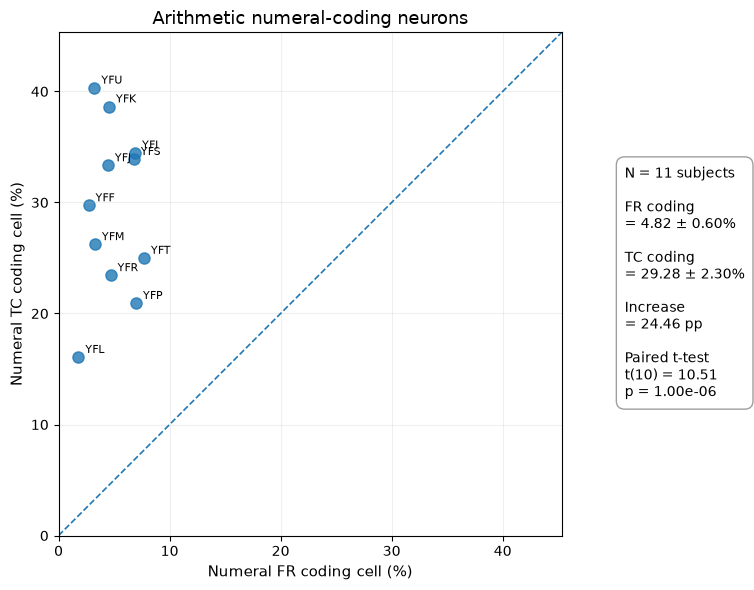


Saved:
c:\Users\shafi\number-simplex-reproduction\figures1\figure1M_numeral_coding_final.png


In [31]:
# ============================================================
# FINAL FIGURE 1M
# SUBJECT-LEVEL FR vs TC NUMERAL-CODING PERCENTAGE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel


# ------------------------------------------------------------
# DATA: one pair per subject
# ------------------------------------------------------------

x = subject_summary["FR_coding_percent"].to_numpy()
y = subject_summary["TC_coding_percent"].to_numpy()

subjects = subject_summary["subject"].to_numpy()

n_subjects = len(subject_summary)


# ------------------------------------------------------------
# PAIRED T-TEST ACROSS SUBJECTS
# ------------------------------------------------------------

t_stat, p_value = ttest_rel(
    y,
    x,
)

difference = y - x

mean_fr = x.mean()
mean_tc = y.mean()

sem_fr = subject_summary[
    "FR_coding_percent"
].sem()

sem_tc = subject_summary[
    "TC_coding_percent"
].sem()

mean_difference = difference.mean()


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("========================================")
print("FIGURE 1M PAIRED T-TEST")
print("========================================")

print(
    f"N subjects: {n_subjects}"
)

print(
    f"\nFR coding: "
    f"{mean_fr:.2f}% ± {sem_fr:.2f}% SEM"
)

print(
    f"TC coding: "
    f"{mean_tc:.2f}% ± {sem_tc:.2f}% SEM"
)

print(
    f"Mean increase: "
    f"{mean_difference:.2f} percentage points"
)

print(
    f"\nt({n_subjects - 1}) = "
    f"{t_stat:.4f}"
)

print(
    f"p = {p_value:.6g}"
)


print("\nCONCLUSION")

if p_value < 0.05:

    print(
        "Reject H0."
    )

    print(
        "The percentage of numeral-coding neurons "
        "is significantly higher for temporal coding "
        "than for firing-rate coding across subjects."
    )

else:

    print(
        "Fail to reject H0."
    )


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 6)
)


# ------------------------------------------------------------
# SUBJECT POINTS
# ------------------------------------------------------------

ax.scatter(
    x,
    y,
    s=65,
    alpha=0.8,
)


# Optional subject labels
for xi, yi, subject in zip(
    x,
    y,
    subjects,
):

    ax.annotate(
        subject,
        (xi, yi),
        xytext=(5, 3),
        textcoords="offset points",
        fontsize=8,
    )


# ------------------------------------------------------------
# IDENTITY LINE
# ------------------------------------------------------------

upper = max(
    x.max(),
    y.max(),
) + 5

ax.plot(
    [0, upper],
    [0, upper],
    "--",
    linewidth=1.2,
)

ax.set_xlim(
    0,
    upper,
)

ax.set_ylim(
    0,
    upper,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)


# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_xlabel(
    "Numeral FR coding cell (%)",
    fontsize=11,
)

ax.set_ylabel(
    "Numeral TC coding cell (%)",
    fontsize=11,
)

ax.set_title(
    "Arithmetic numeral-coding neurons",
    fontsize=13,
)

ax.grid(
    alpha=0.2
)


# ------------------------------------------------------------
# STATISTICS BOX
# ------------------------------------------------------------

stats_text = (
    f"N = {n_subjects} subjects\n\n"
    f"FR coding\n"
    f"= {mean_fr:.2f} ± {sem_fr:.2f}%\n\n"
    f"TC coding\n"
    f"= {mean_tc:.2f} ± {sem_tc:.2f}%\n\n"
    f"Increase\n"
    f"= {mean_difference:.2f} pp\n\n"
    f"Paired t-test\n"
    f"t({n_subjects - 1}) = {t_stat:.2f}\n"
    f"p = {p_value:.2e}"
)

fig.text(
    0.73,
    0.52,
    stats_text,
    fontsize=10,
    va="center",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="0.6",
        alpha=0.95,
    ),
)


plt.tight_layout(
    rect=[0, 0, 0.72, 1]
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

figure_path = (
    ROOT
    / "figures1"
    / "figure1M_numeral_coding_final.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nSaved:")
print(figure_path)

In [32]:
subject_summary[
    [
        "subject",
        "n_neurons",
        "FR_coding_n",
        "TC_coding_n",
        "FR_coding_percent",
        "TC_coding_percent",
    ]
]

,subject,n_neurons,FR_coding_n,TC_coding_n,FR_coding_percent,TC_coding_percent
0,YFF,37,1,11,2.702703,29.729730
1,YFI,29,2,10,6.896552,34.482759
2,YFJ,45,2,15,4.444444,33.333333
3,YFK,44,2,17,4.545455,38.636364
4,YFL,56,1,9,1.785714,16.071429
5,YFM,61,2,16,3.278689,26.229508
6,YFP,43,3,9,6.976744,20.930233
7,YFR,64,3,15,4.687500,23.437500
8,YFS,59,4,20,6.779661,33.898305
9,YFT,52,4,13,7.692308,25.000000


ANOVA test on brain region specificity 

In [33]:
# ============================================================
# FIGURE 1Q
# SUBJECT × BRAIN REGION TC-CODING SUMMARY
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# LOAD OUR COMPLETED FIGURE 1M NEURON TABLE
# ------------------------------------------------------------

path = (
    ROOT
    / "tables1"
    / "figure1M_all_neuron_permutations.csv"
)

df = pd.read_csv(path)


print("Total neurons loaded:", len(df))

print(
    "\nRegions currently present:",
    sorted(df["region"].dropna().unique())
)


# ------------------------------------------------------------
# STANDARDIZE REGION NAMES
# ------------------------------------------------------------

region_map = {
    "hpc": "HPC",
    "ent": "ENT",
    "ec": "ENT",
    "amy": "AMY",
    "phc": "PHC",
    "para-hpc": "PHC",
}

df["region_clean"] = (
    df["region"]
    .astype(str)
    .str.lower()
    .map(region_map)
)


# Safety check
if df["region_clean"].isna().any():

    bad = df.loc[
        df["region_clean"].isna(),
        "region"
    ].unique()

    raise ValueError(
        f"Unrecognized region labels: {bad}"
    )


# ============================================================
# SUBJECT × REGION SUMMARY
# ============================================================

region_summary = (
    df
    .groupby(
        ["subject", "region_clean"],
        observed=True,
    )
    .agg(
        n_neurons=("neuron", "size"),
        n_TC_coding=("TC_coding", "sum"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# CALCULATE PROPORTION / PERCENTAGE
# ------------------------------------------------------------

region_summary["TC_coding_proportion"] = (
    region_summary["n_TC_coding"]
    / region_summary["n_neurons"]
)

region_summary["TC_coding_percent"] = (
    100
    * region_summary["TC_coding_proportion"]
)


# ------------------------------------------------------------
# ORDER
# ------------------------------------------------------------

subject_order = [
    "YFF", "YFI", "YFJ", "YFK", "YFL",
    "YFM", "YFP", "YFR", "YFS", "YFT", "YFU"
]

region_order = [
    "HPC",
    "ENT",
    "AMY",
    "PHC",
]

region_summary["subject"] = pd.Categorical(
    region_summary["subject"],
    categories=subject_order,
    ordered=True,
)

region_summary["region_clean"] = pd.Categorical(
    region_summary["region_clean"],
    categories=region_order,
    ordered=True,
)

region_summary = (
    region_summary
    .sort_values(
        ["subject", "region_clean"]
    )
    .reset_index(drop=True)
)


# ============================================================
# DISPLAY LONG-FORM TABLE
# ============================================================

display(region_summary)


# ============================================================
# DISPLAY MATRIX LIKE FIGURE 1Q
# ============================================================

percentage_matrix = (
    region_summary
    .pivot(
        index="subject",
        columns="region_clean",
        values="TC_coding_percent",
    )
    .reindex(
        index=subject_order,
        columns=region_order,
    )
)

print("\nTC-coding percentage by subject and region:")

display(
    percentage_matrix.round(2)
)


# ============================================================
# REGION-LEVEL SUMMARY FOR THE BARS
# ============================================================

region_bar_summary = (
    region_summary
    .groupby(
        "region_clean",
        observed=False,
    )
    .agg(
        n_subjects=(
            "TC_coding_percent",
            "count"
        ),

        mean_percent=(
            "TC_coding_percent",
            "mean"
        ),

        sem_percent=(
            "TC_coding_percent",
            "sem"
        ),
    )
    .reindex(region_order)
    .reset_index()
)


print("\nRegion-level mean ± SEM:")

display(
    region_bar_summary.round(2)
)


# ============================================================
# SAVE BOTH TABLES
# ============================================================

region_summary.to_csv(
    ROOT
    / "tables1"
    / "figure1Q_subject_region_summary.csv",
    index=False,
)

region_bar_summary.to_csv(
    ROOT
    / "tables1"
    / "figure1Q_region_mean_sem.csv",
    index=False,
)


print("\nSaved Figure 1Q tables.")

Total neurons loaded: 552

Regions currently present: ['amy', 'ent', 'hpc', 'para-hpc']


,subject,region_clean,n_neurons,n_TC_coding,TC_coding_proportion,TC_coding_percent
0,YFF,HPC,36,11,0.305556,30.555556
1,YFF,ENT,1,0,0.000000,0.000000
2,YFI,HPC,21,8,0.380952,38.095238
3,YFI,ENT,8,2,0.250000,25.000000
4,YFJ,HPC,45,15,0.333333,33.333333
5,YFK,HPC,26,10,0.384615,38.461538
6,YFK,PHC,18,7,0.388889,38.888889
7,YFL,HPC,41,5,0.121951,12.195122
8,YFL,ENT,15,4,0.266667,26.666667
9,YFM,HPC,32,5,0.156250,15.625000



TC-coding percentage by subject and region:


region_clean,HPC,ENT,AMY,PHC
subject,,,,
YFF,30.56,0.00,NaN,NaN
YFI,38.10,25.00,NaN,NaN
YFJ,33.33,NaN,NaN,NaN
YFK,38.46,NaN,NaN,38.89
YFL,12.20,26.67,NaN,NaN
YFM,15.62,37.93,NaN,NaN
YFP,20.93,NaN,NaN,NaN
YFR,25.00,NaN,20.83,NaN
YFS,37.84,NaN,27.27,NaN



Region-level mean ± SEM:


,region_clean,n_subjects,mean_percent,sem_percent
0,HPC,11,30.40,3.76
1,ENT,5,23.80,6.35
2,AMY,4,18.41,3.51
3,PHC,1,38.89,NaN



Saved Figure 1Q tables.


In [41]:
# ============================================================
# FIGURE 1Q
# SUBJECT × REGION: COUNT + PERCENTAGE TABLE
# ============================================================

region_summary["count_percent"] = (
    region_summary["n_TC_coding"].astype(int).astype(str)
    + "/"
    + region_summary["n_neurons"].astype(int).astype(str)
    + " ("
    + region_summary["TC_coding_percent"].round(2).astype(str)
    + "%)"
)


count_percentage_matrix = (
    region_summary
    .pivot(
        index="subject",
        columns="region_clean",
        values="count_percent",
    )
    .reindex(
        index=subject_order,
        columns=region_order,
    )
)


display(count_percentage_matrix)


# Save
count_percentage_matrix.to_csv(
    ROOT
    / "tables1"
    / "figure1Q_subject_region_counts_percent.csv"
)

print(
    "Saved:",
    ROOT
    / "tables1"
    / "figure1Q_subject_region_counts_percent.csv"
)

region_clean,HPC,ENT,AMY,PHC
subject,,,,
YFF,11/36 (30.56%),0/1 (0.0%),NaN,NaN
YFI,8/21 (38.1%),2/8 (25.0%),NaN,NaN
YFJ,15/45 (33.33%),NaN,NaN,NaN
YFK,10/26 (38.46%),NaN,NaN,7/18 (38.89%)
YFL,5/41 (12.2%),4/15 (26.67%),NaN,NaN
YFM,5/32 (15.62%),11/29 (37.93%),NaN,NaN
YFP,9/43 (20.93%),NaN,NaN,NaN
YFR,10/40 (25.0%),NaN,5/24 (20.83%),NaN
YFS,14/37 (37.84%),NaN,6/22 (27.27%),NaN


Saved: c:\Users\shafi\number-simplex-reproduction\tables1\figure1Q_subject_region_counts_percent.csv


HPC:116/387,ENT:22/70,AMY:15/77,PHC:7/18.

In [40]:
116/387

0.2997416020671835

In [36]:
22/70

0.3142857142857143

In [37]:
15/77

0.19480519480519481

In [38]:
7/18

0.3888888888888889

FIGURE 1Q REGION SUMMARY


,count,mean,sem
region_clean,,,
HPC,11,30.397,3.758
ENT,5,23.802,6.353
AMY,4,18.412,3.514
PHC,1,38.889,NaN



POOLED NEURON COUNTS


,n_neurons,n_TC_coding,pooled_percent
region_clean,,,
HPC,387,116,29.974
ENT,70,22,31.429
AMY,77,15,19.481
PHC,18,7,38.889


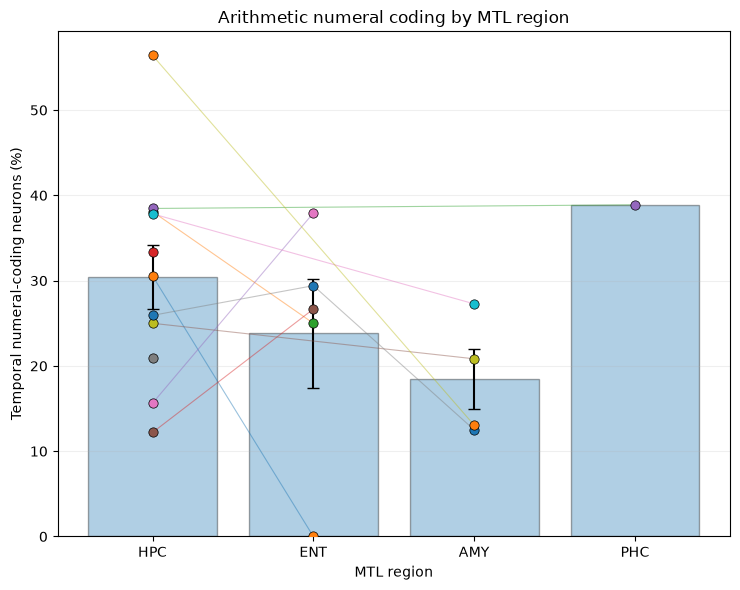


Saved:
c:\Users\shafi\number-simplex-reproduction\figures1\figure1Q_region_specificity.png

MODEL DATA
Number of neurons: 552
Number of subjects: 11

Coding counts by region:


TC_coding,0,1
region_clean,,
HPC,271,116
ENT,48,22
AMY,62,15
PHC,11,7



Saved:
c:\Users\shafi\number-simplex-reproduction\tables1\figure1Q_GLMM_input.csv


In [39]:
# ============================================================
# FIGURE 1Q
# TEMPORAL NUMERAL-CODING PROPORTION BY MTL REGION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

REGION_ORDER = [
    "HPC",
    "ENT",
    "AMY",
    "PHC",
]

SUBJECT_ORDER = [
    "YFF", "YFI", "YFJ", "YFK", "YFL",
    "YFM", "YFP", "YFR", "YFS", "YFT", "YFU",
]


# ============================================================
# 1. USE THE REGION SUMMARY WE ALREADY CREATED
# ============================================================

plot_df = region_summary.copy()

plot_df["region_clean"] = pd.Categorical(
    plot_df["region_clean"],
    categories=REGION_ORDER,
    ordered=True,
)

plot_df["subject"] = pd.Categorical(
    plot_df["subject"],
    categories=SUBJECT_ORDER,
    ordered=True,
)


# ============================================================
# 2. REGION MEAN + SEM ACROSS SUBJECTS
# ============================================================

region_stats = (
    plot_df
    .groupby(
        "region_clean",
        observed=False,
    )["TC_coding_percent"]
    .agg(
        ["count", "mean", "sem"]
    )
    .reindex(REGION_ORDER)
)

print("========================================")
print("FIGURE 1Q REGION SUMMARY")
print("========================================")

display(
    region_stats.round(3)
)


# ============================================================
# 3. POOLED NEURON COUNTS
#    Useful check, but NOT the bar height.
# ============================================================

pooled_region = (
    plot_df
    .groupby(
        "region_clean",
        observed=False,
    )
    .agg(
        n_neurons=("n_neurons", "sum"),
        n_TC_coding=("n_TC_coding", "sum"),
    )
    .reindex(REGION_ORDER)
)

pooled_region["pooled_percent"] = (
    100
    * pooled_region["n_TC_coding"]
    / pooled_region["n_neurons"]
)


print("\n========================================")
print("POOLED NEURON COUNTS")
print("========================================")

display(
    pooled_region.round(3)
)


# ============================================================
# 4. FIGURE 1Q
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 6)
)

x_positions = np.arange(
    len(REGION_ORDER)
)


# ------------------------------------------------------------
# BARS = mean subject-level percentage
# ERROR BARS = SEM
# ------------------------------------------------------------

means = (
    region_stats["mean"]
    .to_numpy(dtype=float)
)

sems = (
    region_stats["sem"]
    .to_numpy(dtype=float)
)


ax.bar(
    x_positions,
    means,
    yerr=sems,
    capsize=4,
    alpha=0.35,
    edgecolor="black",
    linewidth=1,
)


# ============================================================
# 5. CONNECT SAME SUBJECT ACROSS AVAILABLE REGIONS
# ============================================================

for subject in SUBJECT_ORDER:

    sdf = (
        plot_df[
            plot_df["subject"] == subject
        ]
        .copy()
    )

    if len(sdf) == 0:
        continue

    subject_x = []
    subject_y = []

    for region in REGION_ORDER:

        row = sdf[
            sdf["region_clean"] == region
        ]

        if len(row) == 0:
            continue

        subject_x.append(
            REGION_ORDER.index(region)
        )

        subject_y.append(
            float(
                row["TC_coding_percent"].iloc[0]
            )
        )


    # Connect regions belonging to same subject
    if len(subject_x) >= 2:

        ax.plot(
            subject_x,
            subject_y,
            linewidth=0.8,
            alpha=0.45,
            zorder=2,
        )


    # Subject dots
    ax.scatter(
        subject_x,
        subject_y,
        s=45,
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )


# ============================================================
# 6. FORMATTING
# ============================================================

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    REGION_ORDER
)

ax.set_ylabel(
    "Temporal numeral-coding neurons (%)"
)

ax.set_xlabel(
    "MTL region"
)

ax.set_title(
    "Arithmetic numeral coding by MTL region"
)

ax.set_ylim(
    bottom=0
)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()


# ============================================================
# 7. SAVE FIGURE
# ============================================================

figure_path = (
    ROOT
    / "figures1"
    / "figure1Q_region_specificity.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nSaved:")
print(figure_path)


# ============================================================
# 8. SAVE MODEL-READY NEURON TABLE
#
# This is what we will use for the GLMM:
#
# TC_coding ~ region + (1 | subject)
# ============================================================

model_df = df[
    [
        "subject",
        "neuron",
        "region_clean",
        "TC_coding",
    ]
].copy()


# Binary response: False/True -> 0/1
model_df["TC_coding"] = (
    model_df["TC_coding"]
    .astype(int)
)


model_df["region_clean"] = pd.Categorical(
    model_df["region_clean"],
    categories=REGION_ORDER,
    ordered=True,
)


model_path = (
    ROOT
    / "tables1"
    / "figure1Q_GLMM_input.csv"
)

model_df.to_csv(
    model_path,
    index=False,
)


print("\n========================================")
print("MODEL DATA")
print("========================================")

print(
    "Number of neurons:",
    len(model_df)
)

print(
    "Number of subjects:",
    model_df["subject"].nunique()
)

print("\nCoding counts by region:")

display(
    pd.crosstab(
        model_df["region_clean"],
        model_df["TC_coding"],
    )
)

print("\nSaved:")
print(model_path)